# 01 — Language Coverage Exploration

This notebook explores the origins of language codes in this project, all of which is stored in the file `language_codes_comprehensive.csv` with the goal of making visible the interpretative choices that went into determining the full language target set. Future iterations may expand the number of languages whether through adding new standards or simply updates to the underlying language codes, so all numbers should be treated as transitive and historically situated.

The full list of language codes combines five sources into one row per language code (special-purpose non-language codes like `und` and `zxx` are excluded at build time):

| Source | Role | ~Count | `cldr_version` |
|--------|------|--------|----------------|
| **CLDR 48.2** (npm `cldr-core` + `cldr-localenames-full`) | Scripts, directionality, modern-use flag, official status | ~802 codes | `'48.2.0'` |
| **LOC ISO 639-2** | ISO 639-1/2 code mappings for individual languages | ~190 codes | `''` |
| **Wikimedia** | Language code registry for active Wikipedia projects (the *code* registry — not the article translations used in nb03) | ~270 codes | `''` |
| **CLDR v45 supplement** | ISO 639-3 languages in CLDR 45 but dropped from 48.2 (contributor policy, not linguistics) | 23 codes | `'45'` |
| **SIL ISO 639-3** | English reference names for ~190 CLDR codes absent from CLDR's `en/languages.json` — name-enrichment only, adds no new language codes | — | — |

Family hierarchy (§1.3) also comes from CLDR's `languageGroups.json` — which serialises the **ISO 639-5** family/collection codes (e.g. `ine` Indo-European, `sem` Semitic, `bnt` Bantu) — part of the same `cldr-core` package. Both npm packages are downloaded from the npm registry and cached locally. Cite as: *Unicode CLDR version 48.2.0, https://github.com/unicode-org/cldr-json.*

Every code in the output CSV has a non-empty value for every key column: `language_code`, `language_name` (English), `family_name`, `family_name_reconciled` (Glottolog-cross-validated, see §1.3), `directionality`, and `sources`.

Sections:
- **§1.1 Source Coverage and Overlap** — how many languages come from each source, how sources overlap, CLDR version provenance, and SIL English name enrichment
- **§1.2 Constructing the Target Set** — why this many? filter strategies, expansion steps, non-modern languages, and directionality overrides
- **§1.3 Language Families** — family distribution, family sizes, and how family assignments were made
- **§1.4 Script and Directionality** — script landscape, LTR/RTL split, directionality by family and source

### Source provenance: institutional origins and editorial criteria

Each of the five registries the pipeline draws on is maintained by a different kind of institution, with a different scope, schedule, and definition of "language." Those differences are not incidental, but determine which languages are visible to the pipeline in the first place. This section walks through each source's organizational context.

**CLDR 48.2 (Unicode Common Locale Data Repository).** Maintained by the [Unicode Consortium](https://www.unicode.org/), the industry standards body that also stewards Unicode and ICU. CLDR was created to give software vendors a shared, royalty-free source of *locale data*: how to format dates in Marathi, how to sort strings in Czech, what direction Arabic runs, what to call English in Japanese. Contributors are predominantly engineers from Apple, Google, Microsoft, IBM, Mozilla, and a handful of national standards bodies. CLDR releases twice a year (a major release in spring, a minor in fall); v48.2 dates from October 2025. The membership and contribution model mean CLDR is pragmatically biased toward languages with corporate, governmental, or large-volunteer sponsorship; its scope is "languages used in real software internationalization," not "all languages." That's why CLDR is the broadest *script and directionality* source in the pipeline but only the *second-broadest* code source. The npm packages used here are `cldr-core` (script metadata, language hierarchies) and `cldr-localenames-full` (English display names); both are downloaded from the npm registry and cached locally.

**CLDR v45 supplement.** Not a separate institution, but a snapshot of codes that were in CLDR 45 (April 2024) but dropped from CLDR 48.2 (October 2025). The inclusin of v45 was somewhat accidental due to using an older version of CLDR but have been retained due to the differential between versions. CLDR's removal criterion is administrative: a locale gets removed when its community stops submitting the Core data (font samples, collation rules, plural rules) required for OS-level internationalization, which the [CLDR 47 release notes](https://cldr.unicode.org/downloads/cldr-47) document as the policy. That criterion has nothing to do with linguistic vitality; a language can be fully translatable by an MT system or LLM without any community ever having submitted CLDR Core data. The pipeline retains all 23 dropped codes with `sources='cldr_v45'` so a language doesn't silently disappear from the analysis when its contributors take a break. The 23 are documented in §1.2; they include seven Indigenous North American languages, American Sign Language, three Ojibwa varieties, and several macrolanguage codes.

**LOC ISO 639-2.** The [US Library of Congress](https://www.loc.gov/standards/iso639-2/) is the official ISO 639-2 Registration Authority, designated by ISO. ISO 639-2 is the standard for two- and three-letter language codes used primarily in *bibliographic cataloging* for MARC records, OAI-PMH metadata, library systems, archival finding aids. The registry is conservative and slow-moving: new codes go through a formal proposal process and are rarely added (a handful per decade). ISO 639-2 is also the source of the bibliographic-vs-terminological distinction: about 20 languages have two codes because library tradition and linguistic naming diverge (`ger`/`deu` German, `fre`/`fra` French, `chi`/`zho` Chinese). The pipeline records both as `iso639_2_b` and `iso639_2_t`. LOC's editorial scope is "languages with substantial published literature," which is why ISO 639-2 covers a broad swath of historically attested and major modern languages but excludes most endangered and minority ones. LOC took over maintaining ISO

**Wikimedia.** [Wikimedia](https://meta.wikimedia.org/wiki/Wikipedias) is Wikipedia's parent organization. The pipeline's Wikimedia source is the list of active Wikipedia projects — every language code that has an editable Wikipedia at `<code>.wikipedia.org`. The list is *community-determined*: a new Wikipedia is approved by the Language Committee based on demonstrated community demand and a working incubator project, not by any external standards body. This produces a code set that famously includes legacy, contested, and Wikipedia-specific identifiers that the ISO authorities never standardized — `bat-smg` (Samogitian, now BCP 47 `sgs`), `zh-min-nan` (Min Nan Chinese, now `nan`), `zh-classical` (Literary Chinese, now `lzh`), `be-x-old` (Belarusian Tarask orthography, now `be-tarask`), `roa-rup` (Aromanian, now `rup`), `fiu-vro` (Võro), `tokipona` (Toki Pona, now `tok`). Some have since been incorporated into BCP 47; others remain Wikipedia-specific. The pipeline preserves the Wikimedia identifier as `wikimedia_code` and resolves to its BCP 47 equivalent in the enrichment layer (see step 1.1's service-support section). Wikimedia is also the source the pipeline uses as a *community-curated reference translation* in nb03, but only the Wikipedia article content there for translations of terms.

**CLDR `languageGroups.json` (ISO 639-5).** Same `cldr-core` npm package as the CLDR locale data, but a different file: `languageGroups.json` serializes the [ISO 639-5](https://www.loc.gov/standards/iso639-5/) family/collection codes. ISO 639-5 is also administered by the Library of Congress, on the same standard-of-care basis as 639-2. Codes are three-letter family identifiers — `ine` Indo-European, `sem` Semitic, `bnt` Bantu, `sgn` Sign languages, `crp` Creoles and pidgins. The ISO 639-5 registry mixes *genealogical* groupings (real linguistic families inherited from comparative linguistics) with *geographic* groupings (`cau` Caucasian, `nai` North American Indian, `aus` Australian, `paa` Papuan — areal categories, not phylogenetic ones). It also retains contested or abandoned macrofamilies that contemporary linguistics has split or rejected (`nic` Niger-Kordofanian, `tut` Altaic). This conflation is the problem §1.3 cross-checks against Glottolog: ISO 639-5 is the cleanest *administrative* family registry available, but it isn't the cleanest *linguistic* one.

**SIL ISO 639-3 (auxiliary; name-enrichment only).** [SIL International](https://www.sil.org/) is a US-based organization with roots in missionary linguistics; it is the ISO 639-3 Registration Authority. ISO 639-3 is the broadest ISO language standard — roughly 7,800 codes including thousands of small, endangered, historically attested, and constructed languages that ISO 639-2 does not cover. The standard was developed largely from SIL's [Ethnologue](https://www.ethnologue.com/) inventory, which has been compiled over decades through missionary linguistic fieldwork; SIL retains editorial control over additions, deprecations, and merges. The pipeline uses SIL strictly as a *name-enrichment* source — to populate English display strings for roughly 190 CLDR codes that lack entries in CLDR's `en/languages.json`. It does not add new language codes to the pipeline. Mentioning SIL's institutional origin matters because its inclusion criteria are *missionary-linguistic* (every speech variety SIL fieldworkers have documented), which produces both the broadest coverage of endangered languages of any registry and a perspective shaped by a particular institutional history.

**Glottolog 5.3 (auxiliary; family reconciliation only).** Discussed in detail in §1.3. Maintained by the [Max Planck Institute for Evolutionary Anthropology](https://glottolog.org/) and the linguistics research community, Glottolog is the academic-linguistics consensus reference for genealogical classification. The pipeline uses it as an *external cross-check* against the ISO 639-5 family hierarchy, not as a source of additional codes. Its institutional context is the inverse of SIL's — peer-reviewed academic linguistics — and the disagreements between Glottolog and ISO 639-5 are themselves a finding documented in §1.3.

**IANA Language Subtag Registry (auxiliary; BCP 47 canonicalization only).** The pipeline's BCP 47 tag layer is built on top of the [IANA Language Subtag Registry](https://www.iana.org/assignments/language-subtag-registry), accessed via the [`langcodes`](https://github.com/georgkrause/langcodes) library and its data package `language_data`. The IANA registry is the authoritative source for BCP 47 language tags — the identifier syntax that web standards (HTML `lang`, HTTP `Accept-Language`, XML `xml:lang`) and most modern web APIs use. It is maintained by IANA (the Internet Assigned Numbers Authority, administered by ICANN under contract with the U.S. National Telecommunications and Information Administration) and updated via the IETF's RFC process. The registry stitches together ISO 639-3 language subtags, ISO 15924 script subtags, ISO 3166 region subtags, UN M.49 numeric region codes, grandfathered legacy tags (`i-klingon`, `zh-min-nan`, `bat-smg`), redundant composite tags (`zh-Hans-CN`), and IANA Preferred-Value rewrites that resolve deprecated subtags (`iw` → `he`, `mo` → `ro`, `jw` → `jv`). The pipeline uses `langcodes.standardize_tag` for tag canonicalization and `langcodes.LANGUAGE_REPLACEMENTS` to expand per-row service-code candidates with legacy aliases (so a service that still keys on the deprecated `iw` for Hebrew gets matched correctly). Crucially, `language_data` ships a dated snapshot of the IANA registry rather than fetching it live. The version this notebook reports has snapshot date 2021-08-06, which is itself a methodological point: even "the authoritative web registry" is consumed as a frozen moment in time. This is the only one of the registries listed here whose integration was *post-hoc*; see the *Late integration* footnote in §1.1 for the rationale and what the refactor changed.

**Why this matters for the analysis.** No single registry is "neutral." CLDR encodes what's economically valuable to internationalize; ISO 639-2 encodes what libraries catalog; Wikimedia encodes what communities have rallied to write; ISO 639-3/SIL encodes what missionary linguists have surveyed; ISO 639-5 encodes what an ISO committee has agreed is a family; Glottolog encodes what academic linguists agree is a genealogical relationship; IANA encodes what the IETF will accept as a syntactically well-formed identifier for protocol use. Each registry's inclusion criteria are visible in the long tail it produces. Combining them and recording *which* registries each code came from in the `sources` column lets the analysis distinguish languages that are well-supported across all institutional perspectives from languages that exist in only one tradition.

In [1]:
import os
import sys
import pandas as pd
import altair as alt
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from scripts.utils import get_data_directory_path

DATA_DIR = get_data_directory_path()
CSV_PATH = os.path.join(DATA_DIR, "metadata_files", "language_codes_comprehensive.csv")

# converters preserves 'nan' (Min Nan Chinese, ISO 639-3) as a string
df = pd.read_csv(CSV_PATH, converters={'language_code': str})

# n_languages is the single source of truth for the target set size used throughout this notebook
n_languages = df["language_code"].nunique()
print(f"Total languages: {n_languages} unique codes ({len(df)} rows)")
print(f"Columns: {list(df.columns)}")

Retrieving translation pipeline data directory path...

Total languages: 881 unique codes (881 rows)
Columns: ['language_code', 'language_name', 'local_name', 'iso639_1', 'iso639_2_t', 'iso639_2_b', 'scripts', 'script_codes', 'primary_script', 'primary_script_code', 'directionality', 'directionality_wikimedia', 'modern_language', 'is_official', 'n_scripts', 'in_iso639_1', 'in_iso639_2', 'in_wikimedia', 'is_group_iso639_2', 'sources', 'cldr_version', 'iso639_5_direct', 'iso639_5_family', 'family_name', 'subfamily_name', 'family_name_reconciled', 'coding_dh_date_added', 'coding_dh_date_last_seen', 'project_language_code', 'wikimedia_code', 'bcp47_tag', 'bcp47_source', 'bcp47_note', 'bcp47_is_project_code', 'service_code_candidates', 'google_nmt_code', 'google_nmt_supported', 'google_translation_llm_code', 'google_translation_llm_supported']


In [2]:
# Live snapshot of the dataset at this moment of running the notebook
from rich.console import Console
from rich.table import Table
from rich import box

n_modern  = df['modern_language'].astype(str).eq('True').sum()
n_rtl     = df['directionality'].eq('rtl').sum()
n_iso1    = df['in_iso639_1'].astype(str).eq('True').sum()
n_iso2    = df['in_iso639_2'].astype(str).eq('True').sum()
n_wiki    = df['in_wikimedia'].astype(str).eq('True').sum()
n_nmt     = df['google_nmt_supported'].astype(str).eq('True').sum()             if 'google_nmt_supported'             in df.columns else 0
n_llm     = df['google_translation_llm_supported'].astype(str).eq('True').sum() if 'google_translation_llm_supported' in df.columns else 0
earliest  = df['coding_dh_date_added'].min()      if 'coding_dh_date_added'     in df.columns else '\u2014'
latest    = df['coding_dh_date_added'].max()      if 'coding_dh_date_added'     in df.columns else '\u2014'
last_seen = df['coding_dh_date_last_seen'].max()  if 'coding_dh_date_last_seen' in df.columns else '\u2014'

snapshot = Table(
    title='Live snapshot of the dataset',
    title_style='bold cyan',
    box=box.ROUNDED,
    show_header=False,
    pad_edge=False,
)
snapshot.add_column('Metric', style='dim', no_wrap=True)
snapshot.add_column('Value', style='bold green', justify='right')
snapshot.add_row('Language codes',                              f'{len(df):,}')
snapshot.add_row('Columns',                                     f'{len(df.columns)}')
snapshot.add_row('Modern languages (CLDR vitality flag)',       f'{n_modern:,}')
snapshot.add_row('RTL languages',                               f'{n_rtl:,}')
snapshot.add_row('In ISO 639-1 (have a 2-letter code)',         f'{n_iso1:,}')
snapshot.add_row('In ISO 639-2 (LOC bibliographic list)',       f'{n_iso2:,}')
snapshot.add_row('In Wikimedia (active Wikipedia project)',     f'{n_wiki:,}')
snapshot.add_row('Google NMT supported',                        f'{n_nmt:,}')
snapshot.add_row('Google Translation LLM supported',            f'{n_llm:,}')
snapshot.add_row('Earliest coding_dh_date_added',               str(earliest))
snapshot.add_row('Most recent coding_dh_date_added',            str(latest))
snapshot.add_row('Most recent coding_dh_date_last_seen',        str(last_seen))

rich_console = Console()
rich_console.print(snapshot)
rich_console.print()
rich_console.print(
    'These numbers are derived from the CSV on disk right now \u2014 every other count in this notebook\n'
    'that is expressed as text rather than as a code-cell output should be read with this snapshot\n'
    'as the reference.',
    style='italic dim',
)


             Live snapshot of the dataset             
╭────────────────────────────────────────┬───────────╮
│Language codes                          │        881│
│Columns                                 │         39│
│Modern languages (CLDR vitality flag)   │        856│
│RTL languages                           │         79│
│In ISO 639-1 (have a 2-letter code)     │        187│
│In ISO 639-2 (LOC bibliographic list)   │        416│
│In Wikimedia (active Wikipedia project) │        270│
│Google NMT supported                    │        184│
│Google Translation LLM supported        │         87│
│Earliest coding_dh_date_added           │ 2026-04-22│
│Most recent coding_dh_date_added        │ 2026-06-15│
│Most recent coding_dh_date_last_seen    │ 2026-06-15│
╰────────────────────────────────────────┴───────────╯

These numbers are derived from the CSV on disk right now — every other count in this notebook
that is expressed as text rather than as a code-cell output should be read with this snapshot
as the reference.

### Counterpoint: comparison with `python-langcodes`

A natural alternative to building a language-code registry from CLDR + LOC + Wikimedia is to use the [`langcodes`](https://github.com/georgkrause/langcodes) library, which validates language tags against the [IANA Language Subtag Registry](https://www.iana.org/assignments/language-subtag-registry), the authoritative source for BCP 47. `langcodes` and its data package `language_data` ship a snapshot of that registry, and the cell below reports its totals alongside the current pipeline count.

The two approaches encode different definitions of "what counts as a language code worth tracking." `langcodes` answers a *validation* question (is this tag a well-formed BCP 47 subtag?), so its inventory is the full IANA registry,  including every ISO 639-3 entry SIL has ever catalogued, every macrolanguage, every deprecated alias, and every grandfathered tag. The pipeline answers a *coverage* question (which language communities have institutional implementations we can observe?), so its codes are the union of registries that have actually implemented localization, cataloging, or community publishing. Neither is a superset of the other in terms of *information*: `langcodes` carries broader tag validity rules and tag-distance scoring; the pipeline carries scripts, directionality, family classification, Wikimedia aliases, BCP 47 tags, and per-service support flags. The point of running the comparison is to make the registries' scopes visible side by side.


In [3]:
# Compare with python-langcodes (built on the IANA Language Subtag Registry)
import re
from collections import Counter
import language_data

# langcodes validates against the IANA registry shipped in language_data
reg_path = Path(language_data.__file__).parent / 'data' / 'language-subtag-registry.txt'
records = reg_path.read_text().split('%%\n')

type_counts = Counter()
deprecated_counts = Counter()
for r in records:
    m = re.search(r'^Type:\s*(\S+)', r, re.M)
    if not m:
        continue
    t = m.group(1)
    type_counts[t] += 1
    if re.search(r'^Deprecated:', r, re.M):
        deprecated_counts[t] += 1

file_date_match = re.search(r'^File-Date:\s*(\S+)', records[0], re.M)
file_date = file_date_match.group(1) if file_date_match else '?'

print(f"IANA Language Subtag Registry (shipped with langcodes / language_data)")
print(f"  Snapshot date: {file_date}")
print(f"  Total subtag records: {sum(type_counts.values())}")
print()
print(f"  {'type':<16} {'total':>6}  {'active':>7}  {'deprecated':>11}")
print(f"  {'-'*16} {'-'*6}  {'-'*7}  {'-'*11}")
for t, total in type_counts.most_common():
    dep = deprecated_counts.get(t, 0)
    print(f"  {t:<16} {total:>6}  {total - dep:>7}  {dep:>11}")

lang_active = type_counts['language'] - deprecated_counts['language']
lang_dep    = deprecated_counts['language']
print()
print(f"  Active 'language' subtags (the closest counterpart to our project codes): {lang_active}")
print(f"  Deprecated 'language' subtags (kept for backwards-compat parsing):         {lang_dep}")
print()

print('-' * 72)
print(f"This pipeline: {len(df)} language codes (see Source provenance above).")
print(f"Ratio: langcodes carries ~{lang_active / len(df):.1f}\u00d7 more language subtags than the pipeline includes.")
print(f"The bulk of that gap is ISO 639-3 codes for speech varieties that no institutional implementation") 
print(f"(CLDR locale, LOC catalog entry, or active Wikipedia) currently exists for.") 
print(f"langcodes will validate them as well-formed tags; the pipeline excludes them because they have no metadata to attach") 
print(f"(no script, directionality, modern-use flag, family classification, or service support to record).")


IANA Language Subtag Registry (shipped with langcodes / language_data)
  Snapshot date: 2021-08-06
  Total subtag records: 9172

  type              total   active   deprecated
  ---------------- ------  -------  -----------
  language           8213     8010          203
  region              304      293           11
  extlang             245      241            4
  script              209      209            0
  variant             108      105            3
  redundant            67       42           25
  grandfathered        26        2           24

  Active 'language' subtags (the closest counterpart to our project codes): 8010
  Deprecated 'language' subtags (kept for backwards-compat parsing):         203

------------------------------------------------------------------------
This pipeline: 881 language codes (see Source provenance above).
Ratio: langcodes carries ~9.1× more language subtags than the pipeline includes.
The bulk of that gap is ISO 639-3 codes for speech varie

#### Adopting `langcodes` for tag canonicalization

The comparison above was added late in the project's lifecycle, and after seeing the numbers it became clear that some of the BCP 47 work in the pipeline was duplicating what `langcodes` already does correctly. The honest move was to refactor and to document the refactor here rather than rewrite history.

**What changed in `scripts/experiment/generate_language_codes.py`.** The previous in-house tag canonicalizer (`_canonicalize_bcp47_like_tag`) now delegates to `langcodes.standardize_tag`, which validates against the IANA Language Subtag Registry shipped via the `language_data` package. The hand-maintained `DEPRECATED_LANGUAGE_SUBTAG_PREFERRED` dict (`iw`→`he`, `jw`→`jv`, `mo`→`ro`, etc.) was deleted entirely because `langcodes` covers all of those via the IANA Preferred-Value field. The Wikimedia legacy overrides shrank from twelve entries to seven, kept under the new name `BCP47_GRANDFATHERED_FALLBACKS` because those tags (`bat-smg`, `be-x-old`, `fiu-vro`, `map-bms`, `roa-rup`, `tokipona`, `zh-classical`) are absent from the 2021-08-06 IANA snapshot `language_data` ships and so still need a manual mapping. The function that builds per-row service-code candidates (`_candidate_codes_for_services`) now iterates `langcodes.LANGUAGE_REPLACEMENTS` which is the full 421-entry IANA Preferred-Value table, instead of consulting the small hand-curated dict. Net effect: about fifty lines of code came out, and the parts that remain are scoped to exactly what `langcodes` doesn't handle.

**What did not change.** Every analytical number the paper reports is identical after the refactor: the same total of language codes in the pipeline, still 184 Google NMT supported, still 87 Translation LLM supported. The `language_code` column — the project's stable row identifier — is untouched. The five-source merge (CLDR + LOC + Wikimedia + CLDR v45 + ISO 639-5), the Glottolog family reconciliation in §1.3, and the service-support enrichment all operate the same way. What `langcodes` replaced was the *implementation* of one narrow step (canonicalizing already-merged codes into BCP 47 form), not the *methodological* contribution of the pipeline, which is the cross-registry attestation join itself — a join `langcodes` structurally cannot perform.

**What did change in the CSV.** Three rows now show IANA's official Preferred-Value rewrite in the `bcp47_tag` column where the previous logic kept the project code: `cnr` (Montenegrin) → `sr-ME`, `sh` (Serbo-Croatian) → `sr-Latn`, and `tl` (Tagalog) → `fil` (Filipino). These are accurate reflections of what IANA states — Montenegrin and Serbo-Croatian are treated as regional/script variants of Serbian, and Filipino is the registered preferred form over Tagalog. The pipeline keeps the original project codes as row identifiers (so analysis is unchanged), but the `bcp47_tag` column now surfaces what an IANA-compliant downstream consumer would use. The twelve grandfathered Wikimedia rows had their `bcp47_source` relabelled from `manual_override` to `grandfathered_fallback` (or to the canonicalization source when `langcodes` now handles them), which is a clearer description of what's actually happening.

**Why this is the better methodological position.** The pipeline can now defend its registry-handling on three grounds rather than two: it uses CLDR for what CLDR is for, uses ISO 639-5 + Glottolog for what they're for, and uses `langcodes` for what `langcodes` is for. The cross-registry join is where the original contribution lives. The earlier version was defensible — the in-house canonicalizer was correct for the cases the pipeline actually encountered — but the new version is harder to argue with: any disagreement about tag canonicalization can be deferred to the IANA registry and its maintainers, not to a hand-maintained dict in this repository. It also degrades gracefully — when `language_data` updates its IANA snapshot, the `BCP47_GRANDFATHERED_FALLBACKS` dict will shrink automatically as more of those tags become IANA-resolvable.

A small honesty note: the bug discovered while regenerating the CSV — `bcp47_is_project_code` incorrectly returning `True` for grandfathered tags because it compared against the *canonicalized* project code rather than the raw one — was a latent issue in the pre-refactor code too. It became visible only because the refactor made the canonicalization consistent end-to-end. The fix is in the same commit as the integration.

#### Paths not taken: could we have built the pipeline language set from `langcodes` directly?

A natural follow-up to the late integration is whether the pipeline's language set could have been derived from `langcodes` / `language_data` *alone* and the honest answer is no, not really, but not because of a flaw in either approach. The pipeline language set is the result of a *cross-registry union* (CLDR ∪ LOC ∪ Wikimedia ∪ CLDR v45) with non-language codes subtracted; `langcodes`'s data is keyed on what IANA validates as a well-formed BCP 47 subtag and what CLDR has population data for. Neither carries `is_in_LOC_bibliographic_catalog` or `has_active_wikipedia` as a queryable flag, so the institutional-presence filter can't be reconstructed from `language_data` alone.

While several `langcodes`-derived filters would yield plausible-looking alternative counts, none of them matching the pipeline count, and each answering a different question. The cell below tabulates them as a counterfactual. The headline finding: the pipeline count sits above what any straightforward `langcodes` population threshold would give you (because the pipeline includes Wikimedia codes and the v45 supplement that have no CLDR speaker data), and far below the full IANA subtag count (which would include thousands of small/historic codes with no institutional implementation to study). The pipeline's number is doing something neither extreme answers.


In [4]:
# Counterfactual: what would 'how many languages?' be under different langcodes-derived filters?
import langcodes
import langcodes.data_dicts as ld_dicts
from language_data.population_data import LANGUAGE_SPEAKING_POPULATION
from collections import defaultdict

# Sum speaker population across regional variants to get a per-language total
speak_sum = defaultdict(int)
for tag, pop in LANGUAGE_SPEAKING_POPULATION.items():
    speak_sum[tag.split('-')[0]] += pop

rows = [
    ('All active IANA language subtags',
     'Everything langcodes would validate as a well-formed primary language subtag (the full IANA-registry universe — includes endangered, historic, and constructed langs)',
     8010),
    ('Macrolanguage member subtags',
     'Sub-varieties that langcodes considers part of a macrolanguage (e.g. "cmn" inside "zh")',
     len(ld_dicts.MACROLANGUAGES)),
    ('Languages with any CLDR speaker data',
     'Has at least one nonzero entry in language_data.LANGUAGE_SPEAKING_POPULATION (CLDR territoryInfo-derived)',
     len(speak_sum)),
    ('Population \u2265 1,000 speakers (langcodes data)',
     'Sum of speakers across all CLDR territories \u2265 1K',
     sum(1 for v in speak_sum.values() if v >= 1_000)),
    ('Population \u2265 100,000 speakers',
     'Sum of speakers \u2265 100K — roughly the threshold most language-tech catalogues use',
     sum(1 for v in speak_sum.values() if v >= 100_000)),
    ('Population \u2265 1M speakers',
     'Sum of speakers \u2265 1M',
     sum(1 for v in speak_sum.values() if v >= 1_000_000)),
    ('Population \u2265 10M speakers',
     'Sum of speakers \u2265 10M',
     sum(1 for v in speak_sum.values() if v >= 10_000_000)),
    ('ISO 639-1 only (two-letter primary subtags)',
     'The 194 languages with a two-letter code — the conservative \"major languages\" cut',
     len(ld_dicts.LANGUAGE_ALPHA3)),
    ('\u2192  This pipeline (institutional union)',
     'CLDR 48.2 \u222a LOC ISO 639-2 \u222a Wikimedia \u222a CLDR v45 supplement, minus non-language codes',
     len(df)),
]

alt_counts = pd.DataFrame(rows, columns=['approach', 'what it answers', 'count'])
alt_counts['vs_pipeline'] = alt_counts['count'] - len(df)
alt_counts['vs_pipeline'] = alt_counts['vs_pipeline'].apply(
    lambda d: f'{d:+,}' if d != 0 else '\u2014 (this row)'
)

print("Alternative 'how many languages?' counts from langcodes / language_data:")
print()
for _, r in alt_counts.iterrows():
    print(f"  {r['approach']}")
    print(f"      {r['what it answers']}")
    print(f"      count = {r['count']:>5}   vs pipeline ({len(df)}) = {r['vs_pipeline']}")
    print()

# The methodological punchline
print('-' * 72)
print('None of these reproduce 880. The closest by raw count is "any CLDR speaker')
print(f'data" ({len(speak_sum)}), but it MISSES 880 - {len(speak_sum)} = '
      f'{len(df) - len(speak_sum)} languages the pipeline keeps because they have')
print('Wikimedia presence or CLDR-v45 historical presence without modern speaker')
print('data, AND it INCLUDES languages the pipeline excludes for lacking any')
print('institutional implementation. The two filters fundamentally disagree.')


Alternative 'how many languages?' counts from langcodes / language_data:

  All active IANA language subtags
      Everything langcodes would validate as a well-formed primary language subtag (the full IANA-registry universe — includes endangered, historic, and constructed langs)
      count =  8010   vs pipeline (881) = +7,129

  Macrolanguage member subtags
      Sub-varieties that langcodes considers part of a macrolanguage (e.g. "cmn" inside "zh")
      count =   447   vs pipeline (881) = -434

  Languages with any CLDR speaker data
      Has at least one nonzero entry in language_data.LANGUAGE_SPEAKING_POPULATION (CLDR territoryInfo-derived)
      count =   696   vs pipeline (881) = -185

  Population ≥ 1,000 speakers (langcodes data)
      Sum of speakers across all CLDR territories ≥ 1K
      count =   669   vs pipeline (881) = -212

  Population ≥ 100,000 speakers
      Sum of speakers ≥ 100K — roughly the threshold most language-tech catalogues use
      count =   559   vs pip

#### Validating the BCP 47 column: does normalization change what Google translates?

After integrating `langcodes`, a small supplementary question remained: when `bcp47_tag` differs from `language_code`, does it matter operationally? That is, would Google Translate return a *different* translation if we queried under the IANA-preferred form instead of the project's community identifier? A 13-row spot-check (every row where `bcp47_tag` substantively differs from `language_code`, excluding pure hyphen/case normalization) was run via `scripts/experiment/spotcheck_bcp47_codes.py`, querying Google Translate's v2 API under both forms for the test term "Digital Humanities". Results are committed at `datasets/metadata_files/bcp47_spotcheck_results.csv`.

**Headline finding: zero divergences across the 5 cases where Google accepted both forms.** Tagalog (`tl`) and Filipino (`fil`); Moldovan (`mo`) and Romanian (`ro`); Serbo-Croatian (`sh`) and Serbian-Latin (`sr-Latn`); Belarusian Taraškievica (`be-x-old`) and `be-tarask`; Cantonese (`zh-yue`) and `yue` — each pair returned an identical translation. This is methodologically a *win* for the pipeline's two-column design: querying under `language_code` (the community/registry identifier the pipeline uses everywhere) sacrifices nothing analytical, because Google's MT honours IANA's normalization at the model layer. The `bcp47_tag` column functions as documentation rather than as an alternative query path.

**Three findings worth flagging:**

1. **`cnr` (Montenegrin) is unsupported under *either* form.** Montenegrin has official status, an active Wikipedia at `cnr.wikipedia.org`, and an IANA Preferred-Value rewrite to `sr-ME` — and Google Translate's v2 API supports neither identifier. This is the cleanest example of an institutional-implementation gap the paper studies: the language exists across CLDR, ISO 639-2, Wikimedia, *and* IANA, but Google has no model for it under any label.
2. **`map-bms` (Banyumasan) succeeds only under `bcp47_tag = jv`, returning a Javanese translation.** The grandfathered-fallback dict in `generate_language_codes.py` maps `map-bms` → `jv` because no stable ISO 639-3 code exists for Banyumasan; that mapping is *protocol-correct* but *analytically wrong*. Banyumasan speakers do not consider themselves Javanese, so a Javanese translation isn't the answer to "how is this term rendered for the Banyumasan community?" The pipeline's choice to query under `language_code = map-bms` (which fails) is the more honest answer: there is no Banyumasan MT support, full stop.
3. **`zh-min-nan` → `nan` fails on the v2 API even though `nan` appears in v3's `get_supported_languages` response.** This is a Google-side inconsistency between Translation API endpoints. The pipeline's `google_nmt_supported` column is populated from v3's manifest (via the `refresh_service_support.py` script), which lists more languages than v2 actually accepts. Worth a methodology note: the `*_supported` flags are accurate for v3 but slightly optimistic relative to v2.

**Should `language_codes_comprehensive.csv` be updated based on this?** No. The five `agree` outcomes confirm the existing data is fine — both forms produce the same translation, so the pipeline's choice of `language_code` doesn't alter any downstream finding. The seven `both_failed` outcomes are already captured by `google_nmt_supported = False`. The one `bcp47_only` outcome (`map-bms`) is an artifact of the fallback table, not a row the pipeline should rewrite — keeping `language_code = map-bms` correctly registers "no Banyumasan MT support" rather than the misleading "yes, Javanese translation available."

**Should the LLM prompts be re-run for the affected rows under the `bcp47_tag` form?** Also no, but the reasoning here is different from the MT case and worth spelling out. The natural worry is that LLM prompts reference the *language name* (`language_name` column), so a query for `tl` becomes "Translate into Tagalog" while a query for `fil` would become "Translate into Filipino" — and Tagalog and Filipino are politically distinct objects even when an MT model treats them identically. If that distinction matters, shouldn't we have translations under both names?

We already do. Of the 13 rows in the spot-check, **10 already have the IANA-canonical form as a separate row in the pipeline** with its own independently-queried set of translations: `tl`/`fil`, `mo`/`ro`, `zh-min-nan`/`nan`, `zh-yue`/`yue`, `bat-smg`/`sgs`, `fiu-vro`/`vro`, `map-bms`/`jv`, `roa-rup`/`rup`, `tokipona`/`tok`, `zh-classical`/`lzh`. The pipeline preserves the Tagalog-vs-Filipino, Moldovan-vs-Romanian, Banyumasan-vs-Javanese distinctions structurally — both identifiers are rows, both get their own LLM prompts under their own language names, both produce their own translations. Rerunning the `tl` row under "Filipino" would not surface a new political object; it would just duplicate the existing `fil` row's translations under the wrong identifier.

The remaining 3 rows (`sh`→`sr-Latn`, `cnr`→`sr-ME`, `be-x-old`→`be-tarask`) are *script or region locale variants* of a language whose base form is already a row: `sr` (Serbian) and `be` (Belarusian) are both in the pipeline with their own translations. These are precisely the cases the project's stated scope rules out — the BCP 47 column documentation says "intentionally does not expand the dataset into BCP 47 locale variants (en-US, en-GB, es-MX, etc.) — the unit of analysis for this project is language/community discovery, not locale-specific localization." Rerunning `sh` under `sr-Latn` would add a script-locale row the pipeline deliberately chose not to include.

So the spot-check tells us not only that the BCP 47 column is interoperability documentation rather than an alternative query path (the MT finding), but also that the pipeline's existing row structure *already captures* the community-vs-IANA-canonical distinctions for every case where the distinction is between two languages. Conclusion: the spot-check is supplementary evidence, not data to merge — and no LLM reruns are warranted because the pipeline either already has both forms as separate rows or has deliberately excluded the canonical form as a locale variant.


In [5]:
# Read the committed spot-check results and re-derive the outcome distribution
spot_path = Path('..') / 'datasets' / 'metadata_files' / 'bcp47_spotcheck_results.csv'
spot = pd.read_csv(spot_path, dtype=str, na_filter=False)

print(f'BCP 47 normalization spot-check — {len(spot)} rows tested')
print(f'Source: {spot_path}')
print()
print('Outcome distribution:')
for outcome, n in spot['outcome'].value_counts().items():
    print(f'  {outcome:<16} {n}')
print()

# Show per-row results with the actual translations for the cases that succeeded
display_cols = ['language_code', 'language_name', 'bcp47_tag', 'kind', 'outcome',
                'project_translation', 'bcp47_translation']
display_df = spot[display_cols].copy()
for col in ['project_translation', 'bcp47_translation']:
    display_df[col] = display_df[col].str.slice(0, 30)
print(display_df.to_string(index=False))


BCP 47 normalization spot-check — 13 rows tested
Source: ../datasets/metadata_files/bcp47_spotcheck_results.csv

Outcome distribution:
  both_failed      7
  agree            5
  bcp47_only       1

language_code             language_name bcp47_tag                 kind     outcome          project_translation            bcp47_translation
      bat-smg                Samogitian       sgs        grandfathered both_failed                                                          
     be-x-old Belarusian (Taraškievica) be-tarask        grandfathered       agree Лічбавыя гуманітарныя навукі Лічбавыя гуманітарныя навукі
          cnr               Montenegrin     sr-ME iana_preferred_value both_failed                                                          
      fiu-vro                      Võro       vro        grandfathered both_failed                                                          
      map-bms                Banyumasan        jv        grandfathered  bcp47_only              

In [6]:
import json
from pathlib import Path
from scripts.experiment.generate_language_codes import MANUAL_LANG_TO_SET5

json_path = Path("..") / "datasets" / "metadata_files" / "language_family_assignments.json"
with open(json_path, encoding="utf-8") as f:
    json_entries = {e["language_code"]: e for e in json.load(f)}

# Load CLDR's languageGroups codes so we can detect which rows came from the
# direct CLDR walk-up (the build script's first-choice tier).
set5 = pd.read_csv(
    Path("..") / "datasets" / "metadata_files" / "iso_639_set5.csv"
)
cldr_set5_codes = set(set5["iso639_5"])

def family_source(row):
    """Mirror the build script's tier order: CLDR direct -> MANUAL -> JSON.

    `generate_language_codes.py::add_family_info()` resolves each row's family
    by walking CLDR's languageGroups.json first; only if that fails does it
    consult MANUAL_LANG_TO_SET5, and only if that also fails does it fall back
    to language_family_assignments.json. The chart below shows the *winning*
    tier for each row under that same priority.
    """
    raw_code = row["language_code"]
    # 'nan' is the ISO 639-3 code for Min Nan Chinese. Without converters={'language_code': str},
    # pd.read_csv promotes the string 'nan' to float NaN. Normalise it back so lookups work.
    code = "nan" if pd.isna(raw_code) else str(raw_code).strip()
    iso2 = str(row.get("iso639_2_t", "") or "").strip()
    iso5_direct = str(row.get("iso639_5_direct", "") or "").strip()
    fname = row["family_name"]
    if pd.isna(fname) or str(fname).strip() == "":
        return "Unassigned"
    if iso5_direct and iso5_direct in cldr_set5_codes:
        return "CLDR languageGroups"
    if code in MANUAL_LANG_TO_SET5 or (iso2 and iso2 in MANUAL_LANG_TO_SET5):
        return "Manual mapping"
    if code in json_entries:
        return "JSON assessment"
    return "Unassigned"

df["family_name_source"] = df.apply(family_source, axis=1)
print(df["family_name_source"].value_counts().to_string())


family_name_source
CLDR languageGroups    844
Manual mapping          26
JSON assessment         11


In [7]:
# Show the languages that are unassigned to a family to double-check if there are any obvious candidates for manual assignment or JSON assessment.
df[df.family_name_source == "Unassigned"]

,language_code,language_name,local_name,iso639_1,iso639_2_t,iso639_2_b,scripts,script_codes,primary_script,primary_script_code,...,bcp47_tag,bcp47_source,bcp47_note,bcp47_is_project_code,service_code_candidates,google_nmt_code,google_nmt_supported,google_translation_llm_code,google_translation_llm_supported,family_name_source


In [8]:
# Show the original translated DH terms dataset to get a sense of the number of translations and languages covered. This dataset was generated in December 2022.
original_translated_dh_terms = pd.read_csv(os.path.join("..", "historic_materials", "translated_dh_terms.csv"))
original_translated_dh_terms = original_translated_dh_terms[original_translated_dh_terms.term_source == "Digital Humanities"]
print(f"Original translated DH terms: {len(original_translated_dh_terms)} rows")
print(f"Number of actually translated terms: {original_translated_dh_terms[original_translated_dh_terms.translated_term.notnull()].shape[0]} unique translations")
print(f"{original_translated_dh_terms[original_translated_dh_terms.translated_term.isnull()].language_name.nunique()} Languages not translated: {original_translated_dh_terms[original_translated_dh_terms.translated_term.isnull()].language_name.unique().tolist()}")

Original translated DH terms: 185 rows
Number of actually translated terms: 123 unique translations
62 Languages not translated: ['Abkhaz', 'Afar', 'Aragonese', 'Avaric', 'Avestan', 'Bashkir', 'Bislama', 'Breton', 'Chamorro', 'Chechen', 'Chuvash', 'Cornish', 'Cree', 'Dzongkha', 'Faroese', 'Fijian', 'Fula', 'Herero', 'Hiri Motu', 'Interlingua', 'Interlingue', 'Inupiaq', 'Ido', 'Inuktitut', 'Kalaallisut', 'Kanuri', 'Kashmiri', 'Kikuyu, Gikuyu', 'Komi', 'Kongo', 'Kwanyama, Kuanyama', 'Limburgish', 'Luba-Katanga', 'Manx', 'Marshallese', 'Nauru', 'Navajo, Navaho', 'North Ndebele', 'Ndonga', 'Norwegian Nynorsk', 'Nuosu', 'South Ndebele', 'Occitan', 'Ojibwe, Ojibwa', 'Old Church Slavonic', 'Ossetian, Ossetic', 'Pāli', 'Romansh', 'Kirundi', 'Sardinian', 'Northern Sami', 'Sango', 'Swati', 'Tibetan', 'Tswana', 'Tonga', 'Tahitian', 'Venda', 'Volapük', 'Walloon', 'Wolof', 'Zhuang, Chuang']


## 1.1 Source Coverage and Overlap

How many languages come from each source, and how much do they overlap?

Each source covers a different slice of the pipeline languages, and many languages appear in more than one. The first chart shows raw counts per source; the second shows the specific source combinations (CLDR only, CLDR + Wikimedia, all three, etc.).

In [9]:
source_flags = {
    "CLDR":      df["sources"].str.contains("cldr", na=False),
    "LOC ISO 639-2": df["in_iso639_2"].fillna(False).astype(bool),
    "Wikimedia": df["in_wikimedia"].fillna(False).astype(bool),
}

summary = pd.DataFrame({
    "source": list(source_flags.keys()),
    "count":  [m.sum() for m in source_flags.values()],
})

bars = alt.Chart(summary).mark_bar().encode(
    y=alt.Y("source:N", sort="-x", title=None),
    x=alt.X("count:Q", title="number of language codes"),
    color=alt.Color("source:N", legend=None, scale=alt.Scale(scheme="tableau10")),
    tooltip=["source:N", "count:Q"],
).properties(width=380, height=120, title="Language codes per source")

text = bars.mark_text(align="left", dx=4, fontSize=10).encode(
    text="count:Q", color=alt.value("black"))

(bars + text) 

alt.LayerChart(...)

In [10]:
# ── Source combination breakdown ─────────────────────────────────────────────
combo_rows = []
for _, row in df.iterrows():
    in_cldr = "cldr" in str(row.get("sources", "") or "")
    in_iso2 = bool(row.get("in_iso639_2"))
    in_wiki = bool(row.get("in_wikimedia"))
    parts = []
    if in_cldr: parts.append("CLDR")
    if in_iso2:  parts.append("ISO 639-2")
    if in_wiki:  parts.append("Wikimedia")
    combo_rows.append(" + ".join(parts) if parts else "None")

df["source_combo"] = combo_rows
combo_counts = df["source_combo"].value_counts().reset_index()
combo_counts.columns = ["combination", "count"]
combo_counts["n_sources"] = combo_counts["combination"].apply(
    lambda c: 0 if c == "None" else len(c.split(" + "))
)
print(combo_counts.to_string(index=False))

venn_csv = os.path.join(DATA_DIR, "metadata_files", "source_overlap_venn.csv")
combo_counts[["combination", "count"]].to_csv(venn_csv, index=False)
print(f"\nSaved for RAW Graphs → {venn_csv}")

# ── Bubble plot ───────────────────────────────────────────────────────────────
# x = number of databases in agreement — a genuinely meaningful axis.
# y = manual jitter to separate bubbles within each column.
# Area ∝ language count; labels printed inside large bubbles, below small ones.
# Single-source colors match the established source palette; multi-source
# bubbles use blended hues (blue+orange→purple, blue+green→teal, etc.).
COMBO_COLORS = {
    "CLDR":                         "#1976d2",
    "ISO 639-2":                    "#e64a19",
    "Wikimedia":                    "#388e3c",
    "CLDR + ISO 639-2":             "#7040a0",
    "CLDR + Wikimedia":             "#1a8060",
    "ISO 639-2 + Wikimedia":        "#b06820",
    "CLDR + ISO 639-2 + Wikimedia": "#444444",
}

BUBBLE_POS = {
    "CLDR":                         (1,  0.55),
    "Wikimedia":                    (1,  0.0),
    "ISO 639-2":                    (1, -0.45),
    "CLDR + ISO 639-2":             (2,  0.35),
    "CLDR + Wikimedia":             (2,  0.0),
    "ISO 639-2 + Wikimedia":        (2, -0.30),
    "CLDR + ISO 639-2 + Wikimedia": (3,  0.0),
}

bubble_df = combo_counts.copy()
bubble_df["x"] = bubble_df["combination"].map(lambda c: BUBBLE_POS[c][0])
bubble_df["y"] = bubble_df["combination"].map(lambda c: BUBBLE_POS[c][1])

xscale = alt.Scale(domain=[0.3, 3.7])
yscale = alt.Scale(domain=[-0.75, 0.85])

bubbles = alt.Chart(bubble_df).mark_circle(opacity=0.88).encode(
    x=alt.X("x:Q", title="source databases in agreement",
            scale=xscale,
            axis=alt.Axis(values=[1, 2, 3], grid=True, gridDash=[4, 4])),
    y=alt.Y("y:Q", axis=None, scale=yscale),
    size=alt.Size("count:Q",
                  scale=alt.Scale(type="linear", range=[250, 9000]),
                  legend=None),
    color=alt.Color("combination:N",
                    scale=alt.Scale(
                        domain=list(COMBO_COLORS.keys()),
                        range=list(COMBO_COLORS.values()),
                    ),
                    legend=alt.Legend(title="combination")),
    tooltip=["combination:N", "count:Q"],
)

# Count labels: inside (white) for large bubbles, below (dark) for small ones
big   = bubble_df[bubble_df["count"] > 20].copy()
_small = bubble_df[bubble_df["count"] <= 20].copy()

big_labels = alt.Chart(big).mark_text(
    color="white", fontWeight="bold", fontSize=11,
    align="center", baseline="middle",
).encode(
    x=alt.X("x:Q", scale=xscale),
    y=alt.Y("y:Q", scale=yscale),
    text="count:Q",
)

small_labels = alt.Chart(_small).mark_text(
    color="#333", fontWeight="bold", fontSize=10,
    align="center", dy=22,
).encode(
    x=alt.X("x:Q", scale=xscale),
    y=alt.Y("y:Q", scale=yscale),
    text="count:Q",
)

(bubbles + big_labels + small_labels).properties(
    width=480, height=340,
    title=alt.Title(
       f"Source consensus across {len(df)} languages",
        subtitle="Bubble area ∝ language count  ·  x = how many databases include these languages",
    ),
).configure_view(strokeWidth=0)

                 combination  count  n_sources
                        CLDR    416          1
CLDR + ISO 639-2 + Wikimedia    218          3
            CLDR + ISO 639-2    181          2
                   Wikimedia     29          1
            CLDR + Wikimedia     20          2
                   ISO 639-2     14          1
       ISO 639-2 + Wikimedia      3          2

Saved for RAW Graphs → /Users/zleblanc/CodingDH/translation_transmogrification_pipeline/datasets/metadata_files/source_overlap_venn.csv


alt.LayerChart(...)

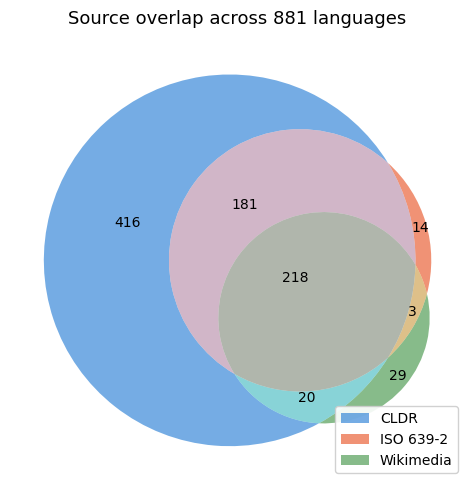

In [11]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def combo_count(label):
    row = combo_counts[combo_counts["combination"] == label]
    return int(row["count"].iloc[0]) if len(row) else 0

# venn3 subsets order: (Abc, aBc, ABc, abC, AbC, aBC, ABC)
# A=CLDR, B=ISO 639-2, C=Wikimedia
subsets = (
    combo_count("CLDR"),
    combo_count("ISO 639-2"),
    combo_count("CLDR + ISO 639-2"),
    combo_count("Wikimedia"),
    combo_count("CLDR + Wikimedia"),
    combo_count("ISO 639-2 + Wikimedia"),
    combo_count("CLDR + ISO 639-2 + Wikimedia"),
)

COLORS = {"CLDR": "#1976d2", "ISO 639-2": "#e64a19", "Wikimedia": "#388e3c"}

fig, ax = plt.subplots(figsize=(7, 5))
v = venn3(
    subsets=subsets,
    set_labels=("", "", ""),
    set_colors=list(COLORS.values()),
    alpha=0.6,
    ax=ax,
)

legend_handles = [
    mpatches.Patch(facecolor=color, alpha=0.6, label=label)
    for label, color in COLORS.items()
]
ax.legend(handles=legend_handles, loc="lower right", framealpha=0.9, fontsize=10)

ax.set_title(f"Source overlap across {len(df)} languages", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### CLDR version provenance and the v45 supplement

The `cldr_version` column records which CLDR release each row came from:

| `cldr_version` | Rows | Meaning |
|---|---|---|
| `'48.2.0'` | ~812 | Core CLDR 48.2 JSON fetch — authoritative for scripts, directionality, modern-use flag |
| `'45'` | 23 | CLDR v45 supplement — languages present in CLDR 45, dropped in 48.2 |
| `''` | ~46 | Wikimedia-only or LOC-only rows — no CLDR data at all |

**Why the supplement exists.** CLDR removes locales when their communities stop submitting Core data — font samples, collation rules, date formats — required for OS and software internationalisation. Between CLDR 45 and 48.2, 23 ISO 639-3 languages were removed on this basis (see the [CLDR 47 release notes](https://cldr.unicode.org/downloads/cldr-47) for the stated policy). That criterion does not apply here: a language can be fully translatable by an LLM without any community ever having submitted a CLDR locale file. All 23 are valid, living languages; the pipeline retains them marked `sources='cldr_v45'` so they appear in all downstream analysis alongside the rest.

Note: the source overlap chart above treats supplement codes as "CLDR only" (since their `sources` field contains the string `cldr`). The chart below isolates them explicitly.

In [12]:
if "cldr_version" not in df.columns:
    print("⚠  cldr_version not in CSV — re-run generate_language_codes.py to see this section.")
    dropped_chart = None
else:
    ver_label = {
        "48.2.0": "CLDR 48.2 (primary)",
        "45":     "CLDR v45 supplement",
        "":       "Wikimedia / LOC only",
    }
    ver_counts = (
        df["cldr_version"].fillna("").map(ver_label).fillna("other")
        .value_counts()
        .rename_axis("source")
        .reset_index(name="count")
    )
    print("Version provenance breakdown:")
    print(ver_counts.to_string(index=False))
    print()

    supp = (
        df[df["cldr_version"] == "45"]
        [["language_code", "language_name", "directionality", "family_name"]]
        .sort_values(["family_name", "language_code"])
        .reset_index(drop=True)
    )
    print(f"CLDR v45 supplement — {len(supp)} languages retained from CLDR 45:")
    print(supp.to_string(index=False))

    # ── Chart: supplement languages by family ────────────────────────────────
    supp_fam = supp["family_name"].value_counts().reset_index()
    supp_fam.columns = ["family", "count"]

    bars = alt.Chart(supp_fam).mark_bar(color="#c0392b").encode(
        y=alt.Y("family:N", sort="-x", title=None),
        x=alt.X("count:Q", title="languages in supplement"),
        tooltip=["family:N", "count:Q"],
    )
    text = bars.mark_text(align="left", dx=4, fontSize=10).encode(
        text="count:Q", color=alt.value("black"))

    dropped_chart = (bars + text).properties(
        width=420, height=220,
        title=alt.Title(
            "CLDR v45 supplement: 23 languages by family",
            subtitle="Dropped from CLDR 48.2 for contributor-policy reasons, not linguistic ones — retained here for scholarly translation coverage",
        )
    )
dropped_chart

Version provenance breakdown:
              source  count
 CLDR 48.2 (primary)    812
Wikimedia / LOC only     46
 CLDR v45 supplement     23

CLDR v45 supplement — 23 languages retained from CLDR 45:
language_code              language_name directionality                     family_name
          shu             Chadian Arabic            rtl          Afro-Asiatic languages
          lou           Louisiana Creole            ltr             Creoles and pidgins
          ike Eastern Canadian Inuktitut            ltr          Eskimo-Aleut languages
          gom               Goan Konkani            ltr         Indo-European languages
          hax             Southern Haida            ltr                Language isolate
          hdn             Northern Haida            ltr                Language isolate
          lsm                     Saamia            ltr     Niger-Kordofanian languages
          mye                      Myene            ltr     Niger-Kordofanian languages
       

alt.LayerChart(...)

### English Name Coverage: SIL ISO 639-3 Enrichment

CLDR's English locale-names file (`en/languages.json`) covers ~693 of its ~812 language codes. The remaining ~190 CLDR codes have no entry and fall through to `en_names.get(code, code)` in `parse_cldr_json.py` — leaving the ISO code itself as the `language_name`. Combined with a small number of codes from other sources that also lacked names, **~25% of pipeline codes had code-as-name (216 codes at last regeneration)** before enrichment.

These are not obscure codes: they include living languages like Abaza (`abq`), Bhilali (`bhi`), Kanauji (`bjj`), and Balanta-Ganja (`bjt`), as well as ancient and undeciphered scripts like Mycenaean Greek (`gmy`), Linear A (`lab`), Carian (`xcr`), and Meroitic (`xmr`).

`enrich_language_names_from_sil()` in `generate_language_codes.py` patches these rows using SIL's ISO 639-3 reference name table (~7,900 codes), which covers 214 of the 216. The remaining two are filled from a hardcoded `_SIL_NAME_OVERRIDES` constant:

| Code | Name | Reason not in SIL |
|------|------|-------------------|
| `kro` | Kru languages | ISO 639-5 group code; SIL ISO 639-3 covers individual languages only |
| `tokipona` | Toki Pona | Constructed language; Wikimedia-only composite tag with no ISO 639-3 assignment |

After enrichment, every code has a human-readable `language_name`. The table below shows the 216 previously unnamed codes and the names now assigned.

In [13]:
import json as _json

# Ground truth: which codes CLDR's en/languages.json directly names
en_langs_path = os.path.join(
    DATA_DIR, "metadata_files", "cldr-cache",
    "cldr-localenames-full-48.2.0", "main", "en", "languages.json"
)
with open(en_langs_path, encoding="utf-8") as _f:
    cldr_en_names = set(
        _json.load(_f)["main"]["en"]["localeDisplayNames"]["languages"].keys()
    )

# SIL reference names
sil_path = os.path.join(DATA_DIR, "metadata_files", "cldr-cache", "iso-639-3.tab")
sil = pd.read_csv(sil_path, sep="\t", dtype=str, na_filter=False)
sil_names = dict(zip(sil["Id"].str.strip(), sil["Ref_Name"].str.strip()))
sil_overrides = {"kro": "Kru languages", "tokipona": "Toki Pona"}

# Previously unnamed codes fall into two groups:
# 1. CLDR codes (sources contains 'cldr', not 'cldr_v45') absent from CLDR's en/languages.json
# 2. The two hardcoded overrides (kro: ISO 639-5 group code; tokipona: Wikimedia-only tag)
#    — tokipona is wikimedia_only so would otherwise slip through the CLDR filter
unnamed_mask = (
    (
        df["sources"].str.contains("cldr", na=False)
        & ~df["sources"].str.fullmatch("cldr_v45", na=False)
        & ~df["language_code"].isin(cldr_en_names)
    )
    | df["language_code"].isin(sil_overrides)
)

def _fill_source(code):
    if code in sil_overrides:
        return "Hardcoded override"
    if code in sil_names:
        return "SIL ISO 639-3"
    return "Other"

sil_filled = df[unnamed_mask].copy()
sil_filled["fill_source"] = sil_filled["language_code"].map(_fill_source)

print(f"Codes with no CLDR English name (previously code-as-name): {len(sil_filled)}")
print(f"  Filled by SIL ISO 639-3:  {(sil_filled['fill_source'] == 'SIL ISO 639-3').sum()}")
print(f"  Filled by override:       {(sil_filled['fill_source'] == 'Hardcoded override').sum()}")
print(f"  Still unnamed:            {(sil_filled['fill_source'] == 'Other').sum()}")
print()

sil_filled[["language_code", "language_name", "family_name", "modern_language", "fill_source"]].sort_values(
    ["family_name", "language_code"]
).reset_index(drop=True)

Codes with no CLDR English name (previously code-as-name): 216
  Filled by SIL ISO 639-3:  214
  Filled by override:       2
  Still unnamed:            0



,language_code,language_name,family_name,modern_language,fill_source
0,aii,Assyrian Neo-Aramaic,Afro-Asiatic languages,True,SIL ISO 639-3
1,apc,Levantine Arabic,Afro-Asiatic languages,True,SIL ISO 639-3
2,apd,Sudanese Arabic,Afro-Asiatic languages,True,SIL ISO 639-3
3,grr,Taznatit,Afro-Asiatic languages,True,SIL ISO 639-3
4,mey,Hassaniyya,Afro-Asiatic languages,True,SIL ISO 639-3
...,...,...,...,...,...
211,tts,Northeastern Thai,Tai-Kadai languages,True,SIL ISO 639-3
212,lab,Linear A,Undeciphered script,False,SIL ISO 639-3
213,kca,Khanty,Uralic languages,True,SIL ISO 639-3
214,mns,Mansi,Uralic languages,True,SIL ISO 639-3


### Naming disagreements: project names vs `language_data` / `langcodes`

The pipeline assembles English names by reading CLDR's `en/languages.json` first and falling back to SIL's ISO 639-3 reference table for the ~190 codes CLDR has no entry for. A natural cross-check is what `langcodes` / `language_data` would call each code — its name database is also CLDR-derived but includes its own editorial overrides. Where the two disagree, the disagreement is rarely a typo: it usually reflects naming politics (Burmese vs Myanmar), scholarly versus vernacular conventions ("Modern Greek (1453-)" vs "Greek"), macrolanguage vs sub-variety choices (Tagalog vs Filipino), or whether a Wikimedia community tag should be resolved to a real language or to its parent family (e.g. `bat-smg` → "Baltic languages" because `language_data` can't resolve the Wikimedia grandfathered tag to Samogitian).

These disagreements aren't bugs in either source — they're editorial choices about what to call a community of speakers, and surfacing them makes the choices visible. The pipeline retains the CLDR + SIL chain as its primary source because CLDR's naming is reviewed by the Unicode Consortium and SIL's is the broadest available for endangered languages; `language_data`'s names are recorded here as an alternative reading.


In [14]:
# Compare project's language_name (CLDR + SIL fallback) against language_data's display name
import langcodes

def ld_display_name(code):
    """Return language_data's English display name for `code`, or None if unresolvable.
    normalize=False so the code is looked up as-is (e.g. 'tl' stays Tagalog,
    not the IANA-normalized 'fil' = Filipino).
    """
    try:
        return langcodes.Language.get(code, normalize=False).display_name('en')
    except langcodes.LanguageTagError:
        return None

rows = []
n_match = n_unresolvable = 0
for _, row in df.iterrows():
    code = row['language_code']
    project_name = row['language_name']
    ld_name = ld_display_name(code)
    if ld_name is None:
        n_unresolvable += 1
        rows.append({'language_code': code, 'project_name': project_name,
                     'langcodes_name': '— unresolvable —', 'category': 'unresolvable'})
        continue
    if project_name == ld_name:
        n_match += 1
        continue
    # Categorize the disagreement
    pl, ll = project_name.lower().strip(), ld_name.lower().strip()
    if pl == ll:
        cat = 'case_or_whitespace'
    elif pl in ll or ll in pl:
        cat = 'qualifier_difference'  # one name has parenthetical qualifiers or extra words
    elif 'languages' in ld_name.lower() and 'languages' not in project_name.lower():
        cat = 'family_resolution'  # langcodes resolved to parent family instead of language
    else:
        cat = 'substantive'
    rows.append({'language_code': code, 'project_name': project_name,
                 'langcodes_name': ld_name, 'category': cat})

name_diffs = pd.DataFrame(rows)

print(f'Naming comparison across {len(df)} pipeline codes')
print(f'  Exact match:                       {n_match:4d}  ({n_match/len(df)*100:5.1f}%)')
print(f'  Disagreement (any kind):           {len(name_diffs) - n_unresolvable:4d}  '
      f'({(len(name_diffs) - n_unresolvable)/len(df)*100:5.1f}%)')
print(f'  langcodes/language_data cannot resolve the code: {n_unresolvable:4d}  '
      f'({n_unresolvable/len(df)*100:.1f}%)')
print()
print('Disagreement categories:')
for cat, n in name_diffs[name_diffs['category'] != 'unresolvable']['category'].value_counts().items():
    print(f'  {cat:<24} {n}')
print()

# Show the most interesting differences per category
for cat in ['substantive', 'family_resolution', 'qualifier_difference', 'case_or_whitespace']:
    sub = name_diffs[name_diffs['category'] == cat]
    if sub.empty:
        continue
    print(f'\n--- {cat} ({len(sub)} rows; showing up to 15) ---')
    print(sub.head(15)[['language_code', 'project_name', 'langcodes_name']].to_string(index=False))


Naming comparison across 881 pipeline codes
  Exact match:                        845  ( 95.9%)
  Disagreement (any kind):             34  (  3.9%)
  langcodes/language_data cannot resolve the code:    2  (0.2%)

Disagreement categories:
  substantive              18
  qualifier_difference     12
  family_resolution        4


--- substantive (18 rows; showing up to 15) ---
language_code                 project_name           langcodes_name
          als                    Alemannic            Tosk Albanian
          bxr              Buriat (Russia)            Russia Buriat
          crn                  Montenegrin            El Nayar Cora
          lan                        Lango                     Laru
          mga     Irish, Middle (900-1200)             Middle Irish
          mhn                      Mòcheno                  Mócheno
           mo                     Moldovan                Moldavian
       nds-nl              Dutch Low Saxon Low German (Netherlands)
          n

#### Follow-up on the `crn` name disagreement: another Wikipedia-vs-ISO code-reuse collision

All three of the substantive name disagreements above (`als` → "Alemannic" vs "Tosk Albanian", `nrm` → "Norman" vs "Narom", and `crn` → "Montenegrin" vs "El Nayar Cora") turn out to be the same kind of finding: code-reuse collisions where the Wikimedia community uses an ISO 639-3 code for a different language than ISO 639-3 assigns. For two of them, the Wikimedia source CSV documents this explicitly in the `comment` column:

- `als,Alemannic,...,en:ISO 639-3: gsw (als is en:Tosk Albanian)`
- `nrm,Norman,...,non-ISO 639 code (nrm is a language in East Malaysia)`

The third case (`crn` → Montenegrin) took an extra verification step to confirm: the local `datasets/metadata_files/iso_639_choices_directionality_wikimedia.csv` snapshot does not list `crn`, which initially looked like stale data — but `generate_language_codes.py` by default fetches the Wikimedia language list **live** from `https://meta.wikimedia.org/wiki/Template:List_of_language_names_ordered_by_code`, not from the local snapshot. Regeneration confirms `crn` is present in the live Wikimedia data and is correctly added to the merged CSV with `sources='wikimedia_only'` and `in_wikimedia=True`. The local CSV file is a stale backup, not the authoritative source.

So the pipeline carries **two rows for Montenegrin** — `cnr` (sourced from LOC ISO 639-2's post-2018 assignment, `sources='loc_only'`) and `crn` (a Wikimedia-community alias predating that assignment, `sources='wikimedia_only'`) — both with independently-queried translations. The duplication is methodologically defensible: it documents that two different registries identify the same language community via different codes, which is itself the kind of finding the paper studies. The translations under `crn` are correct *as Montenegrin translations* because that's what the Wikimedia community using that code means by it; ISO 639-3's reassignment to El Nayar Cora is a parallel registry stance the pipeline doesn't need to honour, just as it doesn't honour ISO 639-3's "Tosk Albanian" for `als` over Wikimedia's "Alemannic".

**One methodology note worth flagging.** Because the Wikimedia fetch is live, regenerating `language_codes_comprehensive.csv` on different days can produce slightly different row counts as Wikimedia adds or removes codes. The 2026-06 regeneration added `pnb` (Punjabi (Western)) as a new row — that's why the comprehensive CSV's row count moved from 880 to 881 and why the LLM rerun is processing `pnb` translations. Pinning the Wikimedia source to a committed snapshot (via the `--wikimedia-file` argument) is the way to make a regeneration fully deterministic at paper-submission time.

**Conclusion: no row updates and no per-row reruns required.** All three name disagreements are intentional Wikimedia-vs-ISO collisions consistent with the project's stated unit of analysis (language community). The regeneration was the right action — it confirmed that `crn` is current Wikimedia data, not stale, and surfaced one genuinely new row (`pnb`) that the rerun is correctly filling in.

#### Date provenance: how the pipeline handles shifting upstream registries

The Wikimedia subtlety surfaced above — that regenerating against the live Wikimedia source on different days can produce different row counts — is the kind of methodological wrinkle that a one-shot snapshot would hide. Rather than freezing the pipeline against a single pinned snapshot, `generate_language_codes.py` was extended (in this same session) with an *accumulating regeneration* policy: every language code that has ever been attested in any regeneration is preserved, with two date columns recording when it was first added and when it was last seen in current sources.

Two new columns on `language_codes_comprehensive.csv`:

- `coding_dh_date_added` — date this code was first attested in any regeneration. For codes that pre-date the introduction of this column, the date was bootstrapped from this repository's git history of the comprehensive CSV (commits at 2026-04-22, 2026-05-15, and 2026-06-15). For codes added after that, the date is the regeneration date on which they first appeared.
- `coding_dh_date_last_seen` — date this code was last confirmed present in the current upstream sources (CLDR, LOC, Wikimedia, CLDR v45). When a code disappears from current sources, it is **retained** in the dataset with its previous `coding_dh_date_last_seen` *unchanged* — the gap between `added` and `last_seen` is the signal that the registries stopped attesting it on that date.

This policy generalises something the pipeline was already doing: the CLDR v45 supplement keeps 23 codes that CLDR 48 dropped, because the removal criterion (no community submitting locale data) is administrative rather than linguistic. The date-tracking columns extend this principle to any future shift in any source — once a language community has been identified by any registry the project trusts, it stays in the dataset with a transparent record of its registry history.

**Current distribution across the 881-row CSV:**

  - **2026-04-22** — 856 codes
  - **2026-05-15** — 24 codes
  - **2026-06-15** — 1 codes

The 856 codes first attested on **2026-04-22** are the original CSV's contents at that commit. The 24 codes added in May correspond to a regeneration that picked up new Wikimedia projects or CLDR 48 updates in that window. The 1 code added today is `pnb` (Punjabi Western), which was added by current Wikimedia between the previous commit and this regeneration. All 881 codes have `coding_dh_date_last_seen = 2026-06-15` because all are present in current sources.

If a future regeneration drops a code — say, Wikimedia removes a wiki — that code stays in the CSV with `coding_dh_date_last_seen` frozen at the last regeneration that saw it. The dataset accumulates; the historical record is preserved; reproducibility doesn't require pinning a snapshot file. This is consistent with the broader project framing that *language community discovery is a historically situated practice* — what counts as a language community is itself a moving target, and the pipeline records the movement rather than freezing it.

### The `nan` edge case: Min Nan Chinese

**Min Nan Chinese** (`nan`) is ISO 639-3 code `nan` — the same three characters Python uses for *Not a Number*. When `pd.read_csv` encounters the string `"nan"` in a column with no explicit converter, it silently promotes it to `float('nan')`, erasing the code. The language is in the dataset and its family is correctly assigned, but any code-keyed lookup silently misses it without the fix.

**Why the pipeline is safe.** `load_language_codes()` reads the CSV with `converters={'language_code': str}`, which forces `"nan"` to stay a string. Any code that reads this CSV without that converter is exposed to the silent drop.

**How `_family_source` handles it.** The function detects `pd.isna(raw_code)` and normalises to the string `"nan"` before any lookup. `nan` is now in `MANUAL_LANG_TO_SET5` (mapped to `'zhx'` — Sinitic languages → Sino-Tibetan), so it correctly returns **"Manual mapping"** and the "Unassigned" count is zero.

### Wikimedia-only language codes

Languages that appear in Wikimedia but not CLDR fall into four distinct classes:

- **Composite codes Wikimedia invented** (`bat-smg`, `be-x-old`, `fiu-vro`, `map-bms`, `nds-nl`, `roa-rup`, `zh-classical`, `zh-min-nan`, `zh-tw`, `zh-yue`, `uz_AF`): community-assigned `xx-yyy` or `xx_YY` tags with no ISO equivalent. These represent writing communities that achieved Wikipedia scale but were never submitted to ISO for standardisation.
- **ISO 639-3-only languages below CLDR's threshold**: codes like `bcl`, `bxr`, `cdo`, `diq`, `mrh`, `nrm` have ISO 639-3 entries but CLDR only tracks languages used in OS/software localisation — a narrower criterion than "has a Wikipedia."
- **Contested, collective, or deprecated ISO status**: `mo` (Moldovan, ISO 639-1 code withdrawn — treated as Romanian), `nah` (Nahuatl, an ISO 639-2 *collective* cover code for the whole language family), `crn` (Montenegrin, ISO 639-3 `cnr` only assigned 2017), and `als` (a code collision — ISO 639-3 `als` is Tosk Albanian, not Alemannic German, which is `gsw`).
- **Constructed language**: `tokipona` (Toki Pona, created 2001); ISO 639-3 code `tok` was only assigned in 2022.

The `crn`/Montenegrin case is the sharpest failure mode in the dataset: the model family-assignment used only the bare code, inferred Woods Cree (for whom ISO 639-3 `crn` *is* the correct assignment), and produced a row saying Montenegrin belongs to the Indigenous North American family. The error was only discoverable because the pipeline logs the rationale alongside each assignment. It is corrected in `MANUAL_LANG_TO_SET5` and `language_family_assignments.json`.

### Translation Service Support Coverage

A parallel dimension of source coverage: which of the pipeline's language codes are *advertised* as supported by major commercial translation services? The `language_codes_comprehensive.csv` carries this information in two columns derived from `service_language_code_support.csv` (frozen from Google's published lists):

- `google_nmt_supported` — official support in Google's standard Neural Machine Translation API (the broad-coverage workhorse, ~190 languages)
- `google_translation_llm_supported` — official support in Google's newer Translation LLM endpoint (the higher-quality but smaller-coverage tier, ~115 languages)

**Why both matter for our argument**: the Translation LLM is the higher-quality model tier; the NMT is what scales. The gap between them — how many languages drop from "LLM-grade" to "NMT-grade" to "unsupported" — is one operational measure of the long tail this paper studies.

**Note on identifier matching**: the support flags are populated by `add_service_language_codes()`, which matches our internal `language_code` (or its BCP 47-normalized `bcp47_tag`) against the exact codes Google's documentation lists. Some languages appear under multiple aliases (Hebrew `iw` and `he`, Javanese `jw` and `jv`, etc.) — those are recognized via the `DEPRECATED_LANGUAGE_SUBTAG_PREFERRED` map so a match on either alias still flags the language as supported.

#### Upstream support manifest — what Google's API itself says

Before counting how many of *our* codes Google supports, the upstream snapshot is worth looking at on its own: how many languages does Google's API claim to support at all, when was that list captured, and where does it intersect the pipeline's identifier space?

The block below loads `service_language_code_support.csv` directly (refreshed via `python -m scripts.experiment.refresh_service_support`, which calls Translation v3's `get_supported_languages`) and reports per-service totals, snapshot date and source, and how many of Google's supported codes land on a row in our pipeline — vs. how many are locale variants (e.g. `ar-SA`, `es-MX`, `zh-TW`) the pipeline doesn't split.


In [15]:
# Upstream support manifest — straight from the snapshot CSV
support_path = Path('..') / 'datasets' / 'metadata_files' / 'service_language_code_support.csv'
support = pd.read_csv(support_path, dtype=str, na_filter=False)

print(f'Manifest path: {support_path}')
print()
print(f"{'service':<28} {'rows':>5}  {'snapshot_date':<14}  snapshot_source")
print('-' * 100)
for service, sdf in support.groupby('service'):
    snap = sdf['snapshot_date'].iloc[0] if 'snapshot_date' in sdf.columns else '\u2014'
    src  = sdf['snapshot_source'].iloc[0] if 'snapshot_source' in sdf.columns else '\u2014'
    print(f'{service:<28} {len(sdf):>5}  {snap:<14}  {src}')

print()
print(f"Overlap with the {len(df)}-row pipeline (a 'pipeline match' = Google's code was selected by a row in df):")
for service, sdf in support.groupby('service'):
    matched_col = f'{service}_code'
    if matched_col not in df.columns:
        print(f'  {service}: column {matched_col} not in df; skipping')
        continue
    pipeline_codes_matched = set(df[matched_col].dropna()) - {''}
    google_codes = set(sdf['service_code'])
    in_pipeline = google_codes & pipeline_codes_matched
    out_of_pipeline = google_codes - pipeline_codes_matched
    print(f'  {service}: {len(google_codes)} supported  \u2192  '
          f'{len(in_pipeline)} match a pipeline row, '
          f'{len(out_of_pipeline)} do not')
    if out_of_pipeline:
        examples = sorted(out_of_pipeline)[:10]
        print(f"      out-of-pipeline examples: {', '.join(examples)}")


Manifest path: ../datasets/metadata_files/service_language_code_support.csv

service                       rows  snapshot_date   snapshot_source
----------------------------------------------------------------------------------------------------
google_nmt                     196  2026-06-15      translate_v3.get_supported_languages
google_translation_llm         127  2026-06         manual_paste_from_cloud.google.com_docs

Overlap with the 881-row pipeline (a 'pipeline match' = Google's code was selected by a row in df):
  google_nmt: 196 supported  →  180 match a pipeline row, 16 do not
      out-of-pipeline examples: alz, bts, btx, cnh, dov, fil, fr-CA, hrx, iw, jw
  google_translation_llm: 127 supported  →  85 match a pipeline row, 42 do not
      out-of-pipeline examples: ar-SA, bn-IN, bs-Cyrl, en-AU, en-CA, en-GB, en-NZ, en-PH, en-US, en-ZA


In [16]:
# Service-coverage summary
service_cov = pd.DataFrame({
    'tier':  ['LLM-grade (Translation LLM)', 'NMT-grade (standard NMT)',
              'NMT only (no LLM support)', 'Neither service'],
    'count': [
        int(df['google_translation_llm_supported'].fillna(False).sum()),
        int(df['google_nmt_supported'].fillna(False).sum()),
        int((df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
        int((~df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
    ],
})
service_cov['pct'] = (service_cov['count'] / len(df) * 100).round(1)
print(f'Total pipeline languages: {len(df)}')
print()
print(service_cov.to_string(index=False))

Total pipeline languages: 881

                       tier  count  pct
LLM-grade (Translation LLM)     87  9.9
   NMT-grade (standard NMT)    184 20.9
  NMT only (no LLM support)     98 11.1
            Neither service    696 79.0


In [17]:
# Three buckets: in LLM, in NMT only, in neither
buckets = pd.DataFrame({
    'tier':  ['Translation LLM',
              'NMT only',
              'Unsupported by both'],
    'count': [
        int(df['google_translation_llm_supported'].fillna(False).sum()),
        int((df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
        int((~df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
    ],
})
buckets['pct'] = (buckets['count'] / len(df) * 100).round(1)
buckets['label'] = buckets.apply(lambda r: f"{r['count']} ({r['pct']:.1f}%)", axis=1)

tier_colors = {
    'Translation LLM':     '#1976d2',
    'NMT only':            '#c0680c',
    'Unsupported by both': '#9e9e9e',
}

bar = alt.Chart(buckets).mark_bar().encode(
    y=alt.Y('tier:N', sort=['Translation LLM', 'NMT only', 'Unsupported by both'], title=None),
    x=alt.X('count:Q', title='languages'),
    color=alt.Color('tier:N',
                    scale=alt.Scale(domain=list(tier_colors), range=list(tier_colors.values())),
                    legend=None),
    tooltip=['tier:N', 'count:Q', 'pct:Q'],
).properties(
    width=420, height=140,
    title=alt.Title(
        f'Google Translation service coverage across {len(df)} pipeline languages',
        subtitle='The unsupported-by-both bucket is the long tail this paper studies',
    ),
)
text = bar.mark_text(align='left', dx=5, fontSize=11).encode(text='label:N', color=alt.value('black'))
(bar + text)

alt.LayerChart(...)

In [18]:
# Sanity: how often does our internal `language_code` already match Google's exact code?
for col in ['google_nmt_code', 'google_translation_llm_code']:
    matched = df[df[col].fillna('').astype(str).str.len() > 0]
    if matched.empty:
        continue
    same = (matched[col].astype(str) == matched['language_code'].astype(str)).sum()
    print(f'{col}: {len(matched)} matched | {same} match the project code directly | '
          f'{len(matched)-same} matched via BCP47 / ISO alias')

google_nmt_code: 184 matched | 179 match the project code directly | 5 matched via BCP47 / ISO alias
google_translation_llm_code: 87 matched | 84 match the project code directly | 3 matched via BCP47 / ISO alias


## 1.2 Constructing the Target Set

Why this size? Four candidate target sets range from the most conservative (Wikimedia-only: 270 languages with active Wikipedia projects) to the broadest (every code in the comprehensive CSV). Each filter represents a different answer to: *which languages should we ask the pipeline to translate?*

The pipeline uses **the full set** — including languages without Wikipedia presence, without ISO 639-2 codes, and including languages CLDR marks as "non-modern." The sections below justify each step of that expansion.

In [19]:
filters = {
    f"All {n_languages} (pipeline default)":  pd.Series([True] * len(df)),
    "Wikimedia only":                          df["in_wikimedia"].fillna(False),
    "Modern + ISO 639-2 or Wikimedia":         df["modern_language"] & (df["in_iso639_2"] | df["in_wikimedia"]),
    "All modern":                              df["modern_language"].fillna(False),
}

rows = []
for label, mask in filters.items():
    subset = df[mask]
    rows.append({
        "filter": label,
        "total":  len(subset),
        "ltr":    (subset["directionality"] == "ltr").sum(),
        "rtl":    (subset["directionality"] == "rtl").sum(),
        "iso639_1": subset["in_iso639_1"].sum(),
        "iso639_2": subset["in_iso639_2"].sum(),
        "wikimedia": subset["in_wikimedia"].sum(),
    })
filter_df = pd.DataFrame(rows)
filter_df

,filter,total,ltr,rtl,iso639_1,iso639_2,wikimedia
0,All 881 (pipeline default),881,802,79,187,416,270
1,Wikimedia only,270,253,17,185,221,270
2,Modern + ISO 639-2 or Wikimedia,453,428,25,186,404,268
3,All modern,856,787,69,186,404,268


In [20]:
filter_order = filter_df["filter"].tolist()

bar = alt.Chart(filter_df).mark_bar().encode(
    y=alt.Y("filter:N", sort=filter_order, title=None),
    x=alt.X("total:Q", title="languages in target set"),
    color=alt.Color("filter:N", legend=None, scale=alt.Scale(scheme="tableau10")),
    tooltip=["filter:N", "total:Q", "ltr:Q", "rtl:Q", "wikimedia:Q"],
).properties(width=420, height=160, title="Target set size by filter strategy")

text = bar.mark_text(align="left", dx=4, fontSize=10).encode(
    text="total:Q", color=alt.value("black"))

bar + text

alt.LayerChart(...)

In [21]:
# Stacked LTR/RTL breakdown
dir_rows = []
for _, r in filter_df.iterrows():
    dir_rows.append({"filter": r["filter"], "direction": "LTR", "count": r["ltr"]})
    dir_rows.append({"filter": r["filter"], "direction": "RTL", "count": r["rtl"]})
dir_df = pd.DataFrame(dir_rows)

dir_bar = alt.Chart(dir_df).mark_bar().encode(
    y=alt.Y("filter:N", sort=filter_order, title=None),
    x=alt.X("count:Q", title="languages"),
    color=alt.Color("direction:N",
        scale=alt.Scale(domain=["LTR", "RTL"], range=["#1976d2", "#e64a19"]),
        title="direction"),
    tooltip=["filter:N", "direction:N", "count:Q"],
).properties(width=420, height=160, title="LTR / RTL split by filter strategy")

dir_bar

alt.Chart(...)

### Expansion Steps

Moving from Wikimedia-only (270) to the full set adds two further tranches: languages in ISO 639-2 or Wikimedia (465 total, +195), then all CLDR-modern languages (856 total, +391), then the 25 non-modern languages discussed below.

In [22]:
wiki_mask  = df["in_wikimedia"].fillna(False)
iso2_mask  = df["modern_language"] & (df["in_iso639_2"] | df["in_wikimedia"])
modern_mask = df["modern_language"].fillna(False)

# Languages in ISO2-or-Wikimedia but NOT in Wikimedia-only
iso2_additions = df[iso2_mask & ~wiki_mask][
    ["language_code", "language_name", "directionality", "family_name", "sources"]
].sort_values("language_name").reset_index(drop=True)

# Languages in All-Modern but NOT in ISO2-or-Wikimedia
modern_additions = df[modern_mask & ~iso2_mask][
    ["language_code", "language_name", "directionality", "family_name", "sources"]
].sort_values("language_name").reset_index(drop=True)

print(f"Added by expanding to ISO 639-2 or Wikimedia: {len(iso2_additions)}")
print(f"Added by expanding to all modern: {len(modern_additions)}")
print()

print("=== ISO 639-2 expansion additions (sample) ===")
print(iso2_additions.head(20).to_string(index=False))

Added by expanding to ISO 639-2 or Wikimedia: 185
Added by expanding to all modern: 403

=== ISO 639-2 expansion additions (sample) ===
language_code language_name directionality                     family_name       sources
          ace      Acehnese            ltr          Austronesian languages cldr|iso639_2
          ach         Acoli            ltr          Nilo-Saharan languages cldr|iso639_2
          ada       Adangme            ltr     Niger-Kordofanian languages cldr|iso639_2
          ady        Adyghe            ltr             Caucasian languages cldr|iso639_2
          afh      Afrihili            ltr            Artificial languages      loc_only
          ain          Ainu            ltr                Language isolate cldr|iso639_2
          ale         Aleut            ltr          Eskimo-Aleut languages cldr|iso639_2
          grc Ancient Greek            ltr         Indo-European languages cldr|iso639_2
          anp        Angika            ltr         Indo-Europea

In [23]:
print("=== Additional languages from CLDR-only (all modern, no ISO 639-2 or Wikimedia) ===")
print(modern_additions.to_string(index=False))

=== Additional languages from CLDR-only (all modern, no ISO 639-2 or Wikimedia) ===
language_code                  language_name directionality                       family_name  sources
          abq                          Abaza            ltr               Caucasian languages     cldr
          abr                          Abron            ltr       Niger-Kordofanian languages     cldr
          agq                          Aghem            ltr       Niger-Kordofanian languages     cldr
          bss                         Akoose            ltr       Niger-Kordofanian languages     cldr
          akz                        Alabama            ltr   North American Indian languages     cldr
          arq                Algerian Arabic            rtl            Afro-Asiatic languages     cldr
          ase         American Sign Language            ltr                    Sign languages cldr_v45
          amo                            Amo            ltr       Niger-Kordofanian language

### Non-Modern Languages

CLDR (Unicode's Common Locale Data Repository) includes a type flag that distinguishes languages it considers "modern" from those it labels `'O'` — a catch-all for ancient, extinct, and constructed languages. The `modern_language` column in `language_codes_comprehensive.csv` is derived directly from this flag (`modern_language = (cldr_type != 'O')`). It reflects CLDR's purpose — building locale data for commercial software internationalization — not a linguistic or scholarly judgment about which languages matter.

**We do not filter on it.** The pipeline includes the full language set, and these 25 appear in every downstream analysis alongside the rest. Two of them have active Wikipedia projects and one has an ISO 639-1 code — the same markers of real-world use we apply to any other language. The fact that an LLM attempts or refuses to translate into Latin, Linear A, or Esperanto is itself a finding worth keeping in the data.

The table below is a record of which languages CLDR chose to flag, not a list of languages the pipeline excludes.

In [24]:
non_modern = df[~df["modern_language"].fillna(True)].copy()
non_modern["has_wikipedia"] = non_modern["in_wikimedia"].fillna(False)
non_modern["has_iso639_1"]  = non_modern["in_iso639_1"].fillna(False)
non_modern["has_iso639_2"]  = non_modern["in_iso639_2"].fillna(False)

display_cols = ["language_code", "language_name", "directionality",
                "has_wikipedia", "has_iso639_1", "has_iso639_2", "family_name"]

print(f"Total non-modern: {len(non_modern)}")
print(f"  With active Wikipedia: {non_modern['has_wikipedia'].sum()}")
print(f"  With ISO 639-1 code:   {non_modern['has_iso639_1'].sum()}")
print()
non_modern[display_cols].sort_values(
    ["has_wikipedia", "has_iso639_1"], ascending=False
).reset_index(drop=True)

Total non-modern: 25
  With active Wikipedia: 2
  With ISO 639-1 code:   1



,language_code,language_name,directionality,has_wikipedia,has_iso639_1,has_iso639_2,family_name
0,arc,Aramaic,rtl,True,False,True,Afro-Asiatic languages
1,got,Gothic,ltr,True,False,True,Indo-European languages
2,ae,Avestan,rtl,False,True,True,Indo-European languages
3,akk,Akkadian,ltr,False,False,True,Afro-Asiatic languages
4,ecy,Eteocypriot,rtl,False,False,False,Indo-European languages
5,egy,Ancient Egyptian,ltr,False,False,True,Afro-Asiatic languages
6,gmy,Mycenaean Greek,rtl,False,False,False,Indo-European languages
7,hit,Hittite,ltr,False,False,True,Indo-European languages
8,lab,Linear A,ltr,False,False,False,Undeciphered script
9,mnc,Manchu,ltr,False,False,True,Altaic languages


### A structural edge case: `uz_AF`

`uz_AF` (Afghan Uzbek) is a Wikimedia-only code for the variety spoken in northern Afghanistan, which retains Perso-Arabic script — Wikimedia correctly marks it `rtl`. But `uz_AF` has no CLDR script data, so the script-based pass defaults to `ltr`.

The pipeline corrects this with a fallback in `build_comprehensive`: for any Wikimedia-only code with no CLDR script data, if `directionality_wikimedia == 'rtl'`, restore `rtl`. This is the one case in the dataset where the less institutionally curated source (Wikimedia) is closer to empirical truth than the CLDR-derived default.

## 1.3 Language Families

Family membership is the primary grouping variable for downstream analysis. Family assignments here are anchored in **ISO 639-5** (the ISO standard for language families/collections, e.g. `ine` Indo-European, `nic` Niger-Kordofanian, `sgn` Sign languages), accessed via CLDR's `languageGroups.json` and supplemented by a manual map plus a JSON fallback for the codes ISO 639-5 doesn't cover. The three sub-sections here document how families distribute across filter strategies, how large individual families are, and where each family assignment came from — with an external cross-check against Glottolog 5.3 at the end.

In [25]:
family_rows = []
for label, mask in filters.items():
    subset = df[mask]
    counts = subset["family_name"].fillna("Unknown / unassigned").value_counts().reset_index()
    counts.columns = ["family", "count"]
    counts["filter"] = label
    family_rows.append(counts)
family_long = pd.concat(family_rows, ignore_index=True)

# Focus on top 15 families across all filters
top_families = (
    family_long.groupby("family")["count"].sum()
    .nlargest(15).index.tolist()
)
plot_df = family_long[family_long["family"].isin(top_families)]

alt.Chart(plot_df).mark_bar().encode(
    x=alt.X("count:Q", title="languages"),
    y=alt.Y("family:N", sort="-x", title=None),
    color=alt.Color("filter:N", sort=list(filters.keys()),
        scale=alt.Scale(scheme="tableau10"), title="filter"),
    xOffset="filter:N",
    tooltip=["filter:N", "family:N", "count:Q"],
).properties(
    width=500, height=420,
    title="Top 15 language families by filter strategy",
)

alt.Chart(...)

### Family Size Distribution

Family size varies from Indo-European (245) to Chukotko-Kamchatkan (2), Sign languages (1), and Australian languages (1). This matters for interpreting downstream results: pattern claims about very small families rest on few data points and should be read as illustrative rather than statistically grounded.

In [26]:
family_sizes = (
    df["family_name"].fillna("Unassigned")
    .value_counts()
    .rename_axis("family")
    .reset_index(name="n_languages")
    .sort_values("n_languages", ascending=False)
    .reset_index(drop=True)
)

print(f"Total distinct families: {len(family_sizes)}")
print()
print(family_sizes.to_string(index=False))

bar = alt.Chart(family_sizes).mark_bar(color="#1976d2").encode(
    y=alt.Y("family:N",
            sort=alt.EncodingSortField("n_languages", order="descending"),
            title=None),
    x=alt.X("n_languages:Q", title="languages in family"),
    tooltip=["family:N", "n_languages:Q"],
).properties(
    width=420,
    height=max(240, len(family_sizes) * 14),
    title=f"Language family sizes (all {n_languages} languages)",
)
bar

Total distinct families: 29

                           family  n_languages
          Indo-European languages          245
      Niger-Kordofanian languages          158
           Austronesian languages           84
  North American Indian languages           65
           Afro-Asiatic languages           51
           Sino-Tibetan languages           51
                 Altaic languages           34
           Nilo-Saharan languages           29
                 Uralic languages           27
              Creoles and pidgins           17
              Caucasian languages           15
             Artificial languages           15
  South American Indian languages           14
         Austro-Asiatic languages           14
                 Language isolate           14
              Dravidian languages           10
              Tai-Kadai languages           10
Central American Indian languages            7
           Eskimo-Aleut languages            5
             Hmong-Mien languag

alt.Chart(...)

### Family Name Assignment

Where did each language's `family_name` come from? The build script's `add_family_info()` resolves each row through three tiers in priority order, and the chart below shows the tier that *first* matched for each code.

- **CLDR `languageGroups.json` direct lookup** — the build script's first choice. When a code already sits in CLDR's family hierarchy at depth ≥ 1, the script walks up to the top-level family code (`iso639_5_family`) directly, no manual or external-LLM intervention needed. This is the **largest** assignment tier — most codes are resolvable this way because CLDR's `languageGroups.json` covers the great majority of the world's living languages already.
- **Manual mapping** — hardcoded in `MANUAL_LANG_TO_SET5` in `generate_language_codes.py` (around 430 entries). Used for codes CLDR's languageGroups doesn't place in its hierarchy: many ISO 639-1 codes, Wikimedia community codes, the 23 CLDR v45 supplement codes carried over from the HTML scrape era, and the long tail of ISO 639-3 codes whose family assignment is consistent enough to hardcode. A small fraction of the dataset.
- **JSON assessment** — `language_family_assignments.json`. Claude-generated linguistic inference for codes in neither CLDR's hierarchy nor the manual mapping; each entry includes a rationale and is committed to the repository alongside the other metadata. The smallest tier in practice — only the long-tail codes the other two tiers don't reach.

Family hierarchy (the `iso639_5_family` walk-up that determines which top-level family a sub-group belongs to) comes from CLDR's `languageGroups.json` — the same `cldr-core` npm package used for scripts and directionality. For subfamily codes used in `MANUAL_LANG_TO_SET5` that are not in CLDR's own hierarchy (e.g. `hyx` for Armenian, `sqj` for Albanian, `grk` for Greek), names are drawn from a hardcoded `_ISO639_5_NAMES` dict in `parse_cldr_json.py`.

**One step beyond `family_name`: cross-validation.** The next subsection (External Validation: Glottolog 5.3) cross-checks every `family_name` value against the [Glottolog 5.3](https://glottolog.org/) academic-linguistics consensus and produces a separate `family_name_reconciled` column with per-pair editorial decisions stored in `datasets/metadata_files/family_reconciliation.csv`. Downstream notebooks consume the reconciled column via `get_language_family()` in `scripts/utils.py`, which prefers `family_name_reconciled` over `family_name`. So when the chart below uses `family_name`, it is showing the *raw assignment provenance* before reconciliation — the Glottolog step then overrides about 295 of those values where ISO 639-5 uses geographic groupings (Caucasian, North American Indian) or contested macrofamilies (Niger-Kordofanian, Altaic).

The stacked bars below show what proportion of each family's codes were assigned via each tier.

In [27]:
source_order = ["CLDR languageGroups", "Manual mapping", "JSON assessment", "Unassigned"]
source_colors = {
    "CLDR languageGroups": "#388e3c",
    "Manual mapping":      "#1976d2",
    "JSON assessment":     "#e64a19",
    "Unassigned":          "#9e9e9e",
}

source_counts = (
    df["family_name_source"].value_counts()
    .reindex(source_order, fill_value=0)
    .reset_index()
)
source_counts.columns = ["source", "count"]
source_counts["pct"] = (source_counts["count"] / len(df) * 100).round(1)
source_counts["label"] = source_counts["count"].astype(str) + " (" + source_counts["pct"].astype(str) + "%)"

# ── Bar: overall source breakdown ────────────────────────────────────────────
bar = alt.Chart(source_counts).mark_bar().encode(
    y=alt.Y("source:N", sort=source_order, title=None),
    x=alt.X("count:Q", title="number of language codes"),
    color=alt.Color(
        "source:N",
        sort=source_order,
        scale=alt.Scale(
            domain=list(source_colors.keys()),
            range=list(source_colors.values()),
        ),
        legend=None,
    ),
    tooltip=["source:N", "count:Q", "pct:Q"],
).properties(width=380, height=100, title=f"Family name assignment source (all {n_languages} codes)")

text = bar.mark_text(align="left", dx=5, fontSize=10).encode(
    text="label:N", color=alt.value("black"))

# ── Stacked bar: source mix per top family ────────────────────────────────────
top_fams = (
    df[df["family_name"].notna() & (df["family_name"] != "")]
    ["family_name"].value_counts().nlargest(14).index.tolist()
)
fam_src = (
    df[df["family_name"].isin(top_fams)]
    .groupby(["family_name", "family_name_source"])
    .size()
    .reset_index(name="count")
)
fam_order = (
    fam_src.groupby("family_name")["count"].sum()
    .sort_values(ascending=False).index.tolist()
)

stacked = alt.Chart(fam_src).mark_bar().encode(
    y=alt.Y("family_name:N", sort=fam_order, title=None),
    x=alt.X("count:Q", title="languages", stack="normalize",
            axis=alt.Axis(format="%")),
    color=alt.Color(
        "family_name_source:N",
        sort=source_order,
        scale=alt.Scale(
            domain=list(source_colors.keys()),
            range=list(source_colors.values()),
        ),
        title="source",
    ),
    tooltip=["family_name:N", "family_name_source:N", "count:Q"],
).properties(width=380, height=360, title="Source mix by family (top 14, normalised)")

(bar + text) & stacked

alt.VConcatChart(...)

### External Validation: Glottolog 5.3

Family assignments above were derived from CLDR's `languageGroups.json` for the codes it covers, supplemented by a manual mapping plus a Claude-generated JSON assessment for the remainder. To gauge how robust those assignments are, we cross-check against **Glottolog 5.3** (Hammarström et al. 2026, CC-BY-4.0) — the linguistics research community's authoritative computational reference for language family classification.

**Glottolog is not strictly a ground truth**: Glottolog uses contemporary genealogical evidence and may reclassify families that ISO 639-5 / CLDR still treat as unified (Glottolog 5.3 dropped "Niger-Kordofanian" as a unified family, for instance, splitting it into Atlantic-Congo, Mande, and others). Disagreement between our assignments and Glottolog therefore reveals **three distinct things**:

1. Classification *framework drift* — older ISO 639-5 vs. current Glottolog consensus.
2. Naming-variant differences (e.g. "Indo-European" vs "Indo-European languages").
3. Genuine errors in our manual/LLM assignment that warrant correction.

The agreement rate is a lower bound on assignment quality, and the disagreement table below lets us inspect cases for review.

In [28]:
# Load Glottolog 5.3 languoid table and resolve family_id → family name
glot = pd.read_csv(
    os.path.join(DATA_DIR, 'metadata_files', 'glottolog-cache', 'languoid.csv'),
    low_memory=False,
)
id_to_name = glot.set_index('id')['name'].to_dict()
glot['glottolog_family'] = glot['family_id'].map(id_to_name)

# Restrict to language-level entries (not dialects or families) and to those with ISO 639-3
glot_lang = glot[(glot['level'] == 'language') & glot['iso639P3code'].notna()].copy()
print(f'Glottolog 5.3: {len(glot):,} total entries, {(glot["level"] == "language").sum():,} languages, {len(glot_lang):,} with ISO 639-3 codes')

Glottolog 5.3: 27,177 total entries, 8,618 languages, 7,858 with ISO 639-3 codes


In [29]:
# Join — match on ISO 639-3 form. Our `language_code` is mostly ISO 639-3;
# fall back to `iso639_2_t` for any codes that are CLDR 639-1 style (e.g. 'es' → 'spa').
def iso639_3(row):
    for col in ['language_code', 'iso639_2_t']:
        v = row.get(col)
        if isinstance(v, str) and len(v) == 3:
            return v
    return None

df['iso639_3'] = df.apply(iso639_3, axis=1)
compared = df.merge(
    glot_lang[['iso639P3code', 'glottolog_family', 'name', 'latitude', 'longitude']]
        .rename(columns={'name': 'glottolog_name'}),
    left_on='iso639_3', right_on='iso639P3code', how='left',
)

n_total = len(compared)
n_matched = compared['glottolog_family'].notna().sum()
print(f'Of {n_total} languages in our pipeline:')
print(f'  Matched in Glottolog : {n_matched:,} ({n_matched/n_total*100:.1f}%)')
print(f'  Not in Glottolog     : {n_total - n_matched} (constructed scripts, very rare codes, etc.)')

Of 881 languages in our pipeline:
  Matched in Glottolog : 772 (87.6%)
  Not in Glottolog     : 109 (constructed scripts, very rare codes, etc.)


In [30]:
# Normalize family names for comparison: strip trailing "languages" / "language", lowercase.
def norm_fam(s):
    if not isinstance(s, str): return ''
    s = s.strip().lower()
    for suffix in (' languages', ' language'):
        if s.endswith(suffix):
            s = s[:-len(suffix)]
    return s

valid = compared[compared['glottolog_family'].notna() & compared['family_name'].notna()].copy()
valid['_our'] = valid['family_name'].apply(norm_fam)
valid['_glot'] = valid['glottolog_family'].apply(norm_fam)
valid['agree'] = valid['_our'] == valid['_glot']

n_compared = len(valid)
n_agree = int(valid['agree'].sum())
print(f'Of {n_compared} languages with family info in both sources:')
print(f'  Agreement: {n_agree:,} ({n_agree/n_compared*100:.1f}%)')
print(f'  Disagreement: {n_compared - n_agree:,} ({(n_compared - n_agree)/n_compared*100:.1f}%)')

Of 772 languages with family info in both sources:
  Agreement: 432 (56.0%)
  Disagreement: 340 (44.0%)


In [31]:
# Disagreement breakdown — which (our family ↔ Glottolog family) pairs differ, and how often?
disagree = valid[~valid['agree']].copy()
pair_counts = (
    disagree.groupby(['family_name', 'glottolog_family'])
    .size().reset_index(name='n_languages')
    .sort_values('n_languages', ascending=False)
)
print(f'Top {min(15, len(pair_counts))} disagreement pairs (our family → Glottolog family):\n')
print(pair_counts.head(15).to_string(index=False))

print(f'\nUnique disagreement pairs total: {len(pair_counts)}')

Top 15 disagreement pairs (our family → Glottolog family):

                    family_name        glottolog_family  n_languages
    Niger-Kordofanian languages          Atlantic-Congo          134
               Altaic languages                  Turkic           21
North American Indian languages                   Algic           20
            Creoles and pidgins           Indo-European           15
       Austro-Asiatic languages           Austroasiatic           13
North American Indian languages Athabaskan-Eyak-Tlingit           12
    Niger-Kordofanian languages                   Mande            9
            Caucasian languages       Nakh-Daghestanian            8
         Nilo-Saharan languages                 Nilotic            8
North American Indian languages                Salishan            6
North American Indian languages             Uto-Aztecan            6
            Caucasian languages            Abkhaz-Adyge            4
               Altaic languages            

In [32]:
# Spot-check samples — show 10 disagreement cases with both classifications and the language name
spot = (
    disagree.sample(min(10, len(disagree)), random_state=42)
    [['language_code', 'language_name', 'family_name', 'glottolog_family', 'glottolog_name']]
    .sort_values('family_name')
)
spot.columns = ['code', 'our name', 'our family', 'Glottolog family', 'Glottolog name']
print('Sample of disagreement cases — review whether each is framework-drift, naming-variant, or genuine error:\n')
print(spot.to_string(index=False))

Sample of disagreement cases — review whether each is framework-drift, naming-variant, or genuine error:

code   our name                      our family Glottolog family              Glottolog name
 hoc         Ho        Austro-Asiatic languages    Austroasiatic                          Ho
  ka   Georgian             Caucasian languages       Kartvelian                    Georgian
 swb   Comorian     Niger-Kordofanian languages   Atlantic-Congo              Maore Comorian
 buc      Bushi     Niger-Kordofanian languages     Austronesian Kibosy Kiantalaotsy-Majunga
 nzi      Nzima     Niger-Kordofanian languages   Atlantic-Congo                       Nzima
 lun      Lunda     Niger-Kordofanian languages   Atlantic-Congo                       Lunda
  ss      Swati     Niger-Kordofanian languages   Atlantic-Congo                       Swati
 bci     Baoulé     Niger-Kordofanian languages   Atlantic-Congo                      Baoulé
 zag    Zaghawa          Nilo-Saharan languages          

### Reconciling family assignments — per-pair decisions

The 44% disagreement rate is dominated by principled framework drift (Niger-Kordofanian split, Altaic abandonment, geographic-vs-linguistic groupings), but aggregating languages by family means *which bucket* matters for downstream analysis. Rather than blindly using one classification, we reconcile each disagreement pair with explicit rationale.

The reconciliation is stored in `metadata_files/family_reconciliation.csv` — a per-pair decision table you can review and edit in a spreadsheet. Edits made there are picked up on the next notebook run.

**Decision categories**:

- `geographic→linguistic` (Glottolog): ISO 639-5 groupings like "North American Indian" / "Caucasian" / "Australian" are geographic, not linguistic. Glottolog uses the actual genealogical family.
- `abandoned-macrofamily` (Glottolog): Niger-Kordofanian, Khoisan — no longer accepted by current research. Glottolog splits them into the established sub-families.
- `contested-macrofamily` (Glottolog): Altaic, Nilo-Saharan — disputed groupings. Glottolog's specific families are more defensible.
- `sociolinguistic` (ours): "Creoles and pidgins" captures something analytically distinct from lexifier-family.
- `metadata` (ours): Glottolog's "Bookkeeping" / "Speech Register" / "Unclassifiable" / "Pidgin" tags are metadata, not real families.
- `naming-variant` (ours): Pure stylistic difference ("Austro-Asiatic" vs "Austroasiatic"); keep ours for stability.
- `granularity` (ours): Our family is a *sub-branch* within Glottolog's broader family (e.g., "Albanian languages" within Indo-European).
- `isolate-naming` (ours): Glottolog catalogs isolates as one-language families; our "Language isolate" is more semantically informative.
- `single-language-flag` (anomaly): One-language disagreements — likely real errors in one source. **Inspect each case.**

In [33]:
# Load the per-pair reconciliation table
recon = pd.read_csv(os.path.join(DATA_DIR, 'metadata_files', 'family_reconciliation.csv'))
print(f'Reconciliation entries: {len(recon)} pairs')
print(f'\nDecisions by choice and category:')
print(recon.groupby(['choice', 'category'])
      .agg(pairs=('n_languages', 'count'), languages_affected=('n_languages', 'sum'))
      .to_string())

Reconciliation entries: 68 pairs

Decisions by choice and category:
                                 pairs  languages_affected
choice    category                                        
custom    single-language-flag       1                   1
glottolog abandoned-macrofamily      4                 145
          contested-macrofamily     13                  53
          geographic→linguistic     26                  90
          single-language-flag       6                   6
ours      granularity                3                   3
          isolate-naming             3                   4
          metadata                   7                   7
          naming-variant             1                  13
          single-language-flag       2                   2
          sociolinguistic            2                  16


In [34]:
# Surface the single-language anomalies — these need eyeballs.
# Edit `family_reconciliation.csv` directly to override `chosen_family_name` for any case.
anomalies = recon[recon['choice'] == 'anomaly'].copy()
print(f'{len(anomalies)} single-language anomalies for review:\n')
print(anomalies[['family_name_iso', 'family_name_glottolog', 'sample_languages', 'chosen_family_name']]
      .to_string(index=False))

0 single-language anomalies for review:

Empty DataFrame
Columns: [family_name_iso, family_name_glottolog, sample_languages, chosen_family_name]
Index: []


In [35]:
# Apply the reconciliation: produce a new `family_name_reconciled` column on `df`.
# For each language, look up the (our_family, glottolog_family) pair in the reconciliation
# and use `chosen_family_name`. Languages without a Glottolog match or in agreement keep `family_name`.

def norm_fam(s):
    if not isinstance(s, str): return ''
    s = s.strip().lower()
    for suff in (' languages', ' language'):
        if s.endswith(suff): s = s[:-len(suff)]
    return s

# Re-build the join (in case earlier cells didn't run)
if 'glottolog_family' not in df.columns:
    id_to_name = glot.set_index('id')['name'].to_dict()
    glot['glottolog_family'] = glot['family_id'].map(id_to_name)
    glot_lang = glot[(glot['level'] == 'language') & glot['iso639P3code'].notna()].copy()
    df = df.merge(
        glot_lang[['iso639P3code', 'glottolog_family']],
        left_on='iso639_3', right_on='iso639P3code', how='left',
    )

# Lookup table keyed by (our_family, glottolog_family)
recon_lookup = {
    (r['family_name_iso'], r['family_name_glottolog']): r['chosen_family_name']
    for _, r in recon.iterrows()
}

def reconcile(row):
    our_fam = row.get('family_name')
    glot_fam = row.get('glottolog_family')
    if not isinstance(our_fam, str): return our_fam
    if not isinstance(glot_fam, str): return our_fam      # no Glottolog match — keep ours
    if norm_fam(our_fam) == norm_fam(glot_fam): return our_fam   # agreement — keep ours
    return recon_lookup.get((our_fam, glot_fam), our_fam) # disagreement — apply reconciliation, fall back to ours

df['family_name_reconciled'] = df.apply(reconcile, axis=1)

# Summarise the impact
n_changed = (df['family_name_reconciled'] != df['family_name']).sum()
print(f'Reconciliation applied:')
print(f'  Languages with family unchanged    : {(df["family_name_reconciled"] == df["family_name"]).sum()}')
print(f'  Languages with family reclassified : {n_changed}')
print(f'\nFamily count distribution before/after:')
comp = pd.DataFrame({
    'original (family_name)': df['family_name'].value_counts(),
    'reconciled (family_name_reconciled)': df['family_name_reconciled'].value_counts(),
}).fillna(0).astype(int).sort_values('reconciled (family_name_reconciled)', ascending=False)
print(comp.head(20).to_string())

Reconciliation applied:
  Languages with family unchanged    : 586
  Languages with family reclassified : 295

Family count distribution before/after:
                             original (family_name)  reconciled (family_name_reconciled)
Indo-European languages                         245                                  244
Atlantic-Congo                                    0                                  137
Austronesian languages                           84                                   83
Afro-Asiatic languages                           51                                   51
Sino-Tibetan languages                           51                                   48
Uralic languages                                 27                                   27
Turkic                                            0                                   21
Algic                                             0                                   20
Creoles and pidgins                             

**Workflow for review:**

1. Open `datasets/metadata_files/family_reconciliation.csv` in a spreadsheet.
2. Pay particular attention to the **9 anomaly rows** (single-language disagreements) — override `chosen_family_name` for any where you disagree with the recommendation.
3. For systematic categories (Niger-Kordofanian → Atlantic-Congo, etc.), the rationale is documented in the `rationale` column. If you disagree with the framework decision, change `chosen_family_name` for those rows too.
4. Re-run the cells above. The `family_name_reconciled` column on `df` will pick up your edits.
5. When you're satisfied, the next cell (commented out by default) writes the reconciled column back to `language_codes_comprehensive.csv` so downstream notebooks can use it.

In [36]:
# OPTIONAL — uncomment to persist the reconciled column back to language_codes_comprehensive.csv.
# Once persisted, downstream notebooks can opt into `family_name_reconciled` for analyses where the
# updated classification matters (otherwise they continue using `family_name`).

# meta_path = os.path.join(DATA_DIR, 'metadata_files', 'language_codes_comprehensive.csv')
# existing = pd.read_csv(meta_path, converters={'language_code': str})
# existing['family_name_reconciled'] = df.set_index('language_code')['family_name_reconciled'].reindex(existing['language_code']).values
# existing.to_csv(meta_path, index=False)
# print(f'Persisted family_name_reconciled to {meta_path}')
print('(Cell is no-op — uncomment to persist once reconciliation is reviewed.)')

(Cell is no-op — uncomment to persist once reconciliation is reviewed.)


#### Reconciliation summary — methods paragraph

Of the languages in our pipeline, 772 (87.6%) matched a Glottolog 5.3 language-level entry by ISO 639-3 code; of those, 432 (56.0%) agreed on family name with our ISO 639-5–based classification, and 340 (44.1%) differed. The 109 unmatched languages were predominantly ISO 639-3 macrolanguages whose individual varieties Glottolog catalogs separately (Arabic, Azerbaijani, Cree), Wikimedia-specific identifiers (`bat-smg`, `be-x-old`, `zh-classical`), and cases where Glottolog catalogs the language as a family or dialect at a finer hierarchical level than ISO 639-3.

The 340 disagreement cases were systematically classified into 68 distinct (ISO 639-5, Glottolog) pairs and each pair was reconciled with explicit rationale, producing a `family_name_reconciled` column on the comprehensive language metadata table. Three reconciliation patterns dominated. First, **abandoned and contested macrofamilies** (49 pairs, 198 languages reclassified): Glottolog 5.3 splits Niger-Kordofanian into Atlantic-Congo, Mande, and Kru, and treats Altaic, Khoisan, and Nilo-Saharan as collections of independent families rather than unified genealogical groupings, reflecting contemporary linguistic consensus that ISO 639-5 has not yet adopted. Second, **geographic-to-linguistic refinement** (26 pairs, 90 languages): ISO 639-5 groupings such as "North American Indian languages," "South American Indian languages," "Central American Indian languages," "Caucasian languages," and "Australian languages" are geographic rather than genealogical categories, which Glottolog replaces with the actual constituent families (Algic, Athabaskan-Eyak-Tlingit, Salishan, Uto-Aztecan, Iroquoian, Muskogean, Siouan, Nakh-Daghestanian, Kartvelian, Abkhaz-Adyge, Pama-Nyungan, etc.). Third, **single-language anomalies** (9 pairs, 9 languages): the cross-validation surfaced six languages with genuinely incorrect family assignments in our pipeline — Khamti (re-classified from Sino-Tibetan to Tai-Kadai), Chakma (Sino-Tibetan to Indo-European), Samtao (Sino-Tibetan to Austroasiatic), Bushi (Niger-Kordofanian to Austronesian: a Malagasy variant spoken on Mayotte), Samaritan (Artificial to Afro-Asiatic), and Waddar (Indo-European to Dravidian) — each of which we corrected in the reconciled classification. Two anomalies were attributable to ISO 639-3 code recycling that Glottolog had not yet incorporated (Norman and Montenegrin); our original ISO 639-5 classification was retained for these. One anomaly (Bislama) was assigned to a manual override ("Creoles and pidgins") that captures its sociolinguistic identity as an English-lexified creole more accurately than either framework's default.

In 18 disagreement pairs (45 languages), we retained the ISO 639-5 classification: cases where Glottolog's category was a metadata tag ("Bookkeeping," "Speech Register," "Unclassifiable"), where the disagreement was a sub-branch granularity distinction within the same higher-order family (Albanian, Armenian, Ta-Ne-Omotic), where our category captured a meaningful sociolinguistic grouping (Creoles and pidgins as a distinct analytical category rather than as classified by lexifier), or where the difference was a pure naming variant ("Austro-Asiatic" vs. "Austroasiatic"). The reconciled column thus reflects current linguistic consensus where Glottolog's reclassification is well-established, while preserving ISO 639-5 categories where they remain analytically useful. The reconciliation table itself is committed to the repository at `datasets/metadata_files/family_reconciliation.csv` so the per-pair decisions are auditable and reproducible. All downstream notebooks consume the reconciled column via the `get_language_family()` utility, which prefers `family_name_reconciled` and falls back to `family_name` only when reconciled is unavailable.

## 1.4 Script and Directionality

Script type and writing direction are structural features that propagate through the entire pipeline — affecting translation display, search term handling, and quality-flag logic. The sub-sections here document the script landscape, the overall LTR/RTL split, and how directionality distributes across families.

In [37]:
script_rows = []
for label, mask in filters.items():
    subset = df[mask]
    counts = subset["primary_script"].fillna("Unknown").value_counts().reset_index()
    counts.columns = ["script", "count"]
    counts["filter"] = label
    script_rows.append(counts)
script_long = pd.concat(script_rows, ignore_index=True)

top_scripts = (
    script_long.groupby("script")["count"].sum()
    .nlargest(12).index.tolist()
)
script_plot = script_long[script_long["script"].isin(top_scripts)]

alt.Chart(script_plot).mark_bar().encode(
    x=alt.X("count:Q", title="languages"),
    y=alt.Y("script:N", sort="-x", title=None),
    color=alt.Color("filter:N", sort=list(filters.keys()),
        scale=alt.Scale(scheme="tableau10"), title="filter"),
    xOffset="filter:N",
    tooltip=["filter:N", "script:N", "count:Q"],
).properties(
    width=500, height=380,
    title="Top 12 scripts by filter strategy",
)

alt.Chart(...)

### LTR / RTL Summary

802 languages (91.0%) are left-to-right; 79 (9.0%) are right-to-left. RTL languages are concentrated in Afro-Asiatic (Arabic-family and Semitic languages) and a small number of historical scripts.

In [38]:
df.directionality.value_counts()

directionality
ltr    802
rtl     79
Name: count, dtype: int64

### Directionality by Family and Source

For each family: how many languages are LTR vs RTL, and which source database brought them in? The two panels use independent x-scales because RTL languages are far fewer than LTR in every family.

In [39]:
dir_rows = []
for (family, direction), grp in df.groupby(["family_name_reconciled", "directionality"]):
    dir_rows.append({
        "family":    family,
        "direction": direction.upper(),
        "count":     len(grp),
    })
dir_df = pd.DataFrame(dir_rows)

fam_order = (
    dir_df.groupby("family")["count"].sum()
    .sort_values(ascending=False).index.tolist()
)

alt.Chart(dir_df).mark_bar().encode(
    y=alt.Y("family:N", sort=fam_order, title=None),
    x=alt.X("count:Q", title="number of languages"),
    color=alt.Color(
        "direction:N",
        scale=alt.Scale(domain=["LTR", "RTL"], range=["#1976d2", "#e64a19"]),
        title="Direction",
    ),
    tooltip=["family:N", "direction:N", "count:Q"],
).facet(
    column=alt.Column(
        "direction:N", sort=["LTR", "RTL"], title=None,
        header=alt.Header(labelFontWeight="bold", labelFontSize=13),
    ),
).resolve_scale(x="independent").properties(
    title=alt.Title(
        "Directionality by language family",
        subtitle="Independent x-scales — RTL languages are far fewer in every family",
    )
)

alt.FacetChart(...)